In [ ]:
#Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [ ]:
#Simulation Setup

In [3]:
# Time settings
T = 50          # number of time steps
dt = 1.0        # time step size

# State transition matrix A (4x4)
A = np.array([
    [1, 0, dt, 0],
    [0, 1, 0, dt],
    [0, 0, 1,  0],
    [0, 0, 0,  1]
])

# Observation matrix H (2x4): observe position only
H = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0]
])
# Process noise covariance Q (constant-velocity with random acceleration)
sigma_a = 0.2  # std of acceleration noise
q = sigma_a**2

Q = q * np.array([
    [dt**4 / 4,        0,        dt**3 / 2,      0],
    [0,        dt**4 / 4,        0,        dt**3 / 2],
    [dt**3 / 2,        0,        dt**2,          0],
    [0,        dt**3 / 2,        0,        dt**2]
])

# Measurement noise covariance R
sigma_r = 1.0  # std of measurement noise
R = (sigma_r**2) * np.eye(2)

# Initial true state (position + velocity)
x0_true = np.array([0.0, 0.0, 1.0, 0.5])  # starting at origin, moving diagonally

# Initial estimates for Kalman filter
x0_est = np.array([0.0, 0.0, 0.0, 0.0])   # naive initial guess
P0 = np.eye(4) * 10.0                     # large initial uncertainty

In [ ]:
#State space model

In [4]:
def simulate_system(T, A, H, Q, R, x0):
    n_state = A.shape[0]
    n_obs = H.shape[0]

    x_true = np.zeros((T, n_state))
    y_obs = np.zeros((T, n_obs))

    x_true[0] = x0

    for t in range(1, T):
        # Process noise ~ N(0, Q)
        w_t = np.random.multivariate_normal(mean=np.zeros(n_state), cov=Q)
        x_true[t] = A @ x_true[t - 1] + w_t

    for t in range(T):
        # Measurement noise ~ N(0, R)
        v_t = np.random.multivariate_normal(mean=np.zeros(n_obs), cov=R)
        y_obs[t] = H @ x_true[t] + v_t

    return x_true, y_obs

x_true, y_obs = simulate_system(T, A, H, Q, R, x0_true)

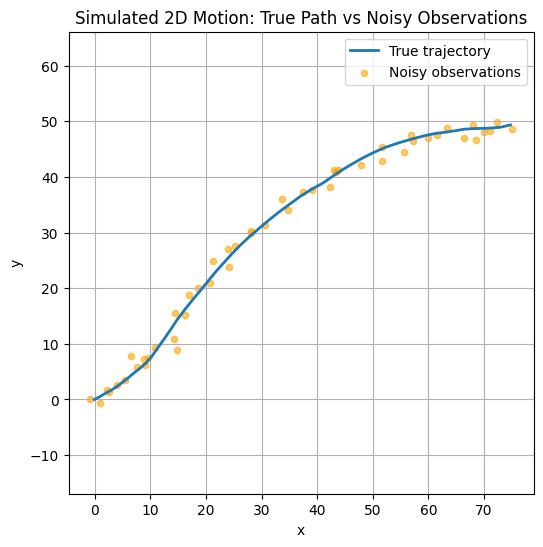

In [5]:
plt.figure(figsize=(6, 6))
plt.plot(x_true[:, 0], x_true[:, 1], label="True trajectory", linewidth=2)
plt.scatter(y_obs[:, 0], y_obs[:, 1], color="orange", alpha=0.6, label="Noisy observations", s=20)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Simulated 2D Motion: True Path vs Noisy Observations")
plt.legend()
plt.axis("equal")
plt.grid(True)
plt.show()

In [ ]:
#Kalman filter implementation

In [6]:
def kalman_filter(y_obs, A, H, Q, R, x0_est, P0):
    T = y_obs.shape[0]
    n_state = A.shape[0]

    x_pred = np.zeros((T, n_state))  # x_{t|t-1}
    P_pred = np.zeros((T, n_state, n_state))

    x_filt = np.zeros((T, n_state))  # x_{t|t}
    P_filt = np.zeros((T, n_state, n_state))

    # Initialize
    x_filt[0] = x0_est
    P_filt[0] = P0

    I = np.eye(n_state)

    for t in range(1, T):
        # 1. Predict
        x_pred[t] = A @ x_filt[t - 1]
        P_pred[t] = A @ P_filt[t - 1] @ A.T + Q

        # 2. Update
        S_t = H @ P_pred[t] @ H.T + R               # innovation covariance
        K_t = P_pred[t] @ H.T @ np.linalg.inv(S_t)  # Kalman gain

        y_t = y_obs[t]
        y_pred = H @ x_pred[t]
        innovation = y_t - y_pred

        x_filt[t] = x_pred[t] + K_t @ innovation
        P_filt[t] = (I - K_t @ H) @ P_pred[t]

    return x_pred, P_pred, x_filt, P_filt

x_pred, P_pred, x_filt, P_filt = kalman_filter(y_obs, A, H, Q, R, x0_est, P0)
    

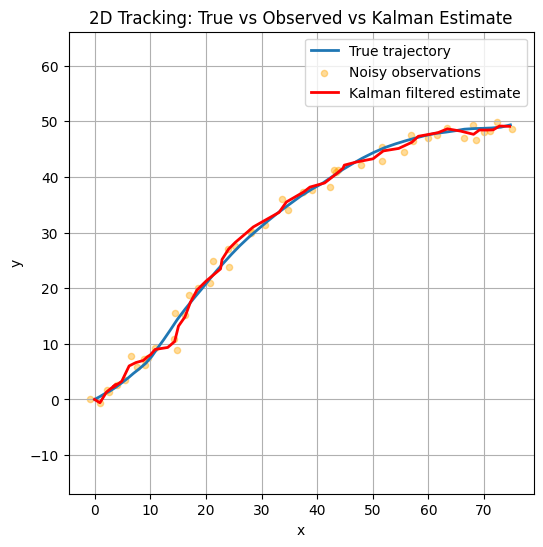

In [7]:
plt.figure(figsize=(6, 6))
plt.plot(x_true[:, 0], x_true[:, 1], label="True trajectory", linewidth=2)
plt.scatter(y_obs[:, 0], y_obs[:, 1], color="orange", alpha=0.4, label="Noisy observations", s=20)
plt.plot(x_filt[:, 0], x_filt[:, 1], color="red", label="Kalman filtered estimate", linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Tracking: True vs Observed vs Kalman Estimate")
plt.legend()
plt.axis("equal")
plt.grid(True)
plt.show()

In [ ]:
#Baseline estimation

In [8]:
# Position errors
error_obs = y_obs - x_true[:, :2]
error_kalman = x_filt[:, :2] - x_true[:, :2]

# Euclidean position error at each time step
distance_error_obs = np.sqrt(np.sum(error_obs**2, axis=1))
distance_error_kalman = np.sqrt(np.sum(error_kalman**2, axis=1))

# RMSE
rmse_obs = np.sqrt(np.mean(distance_error_obs**2))
rmse_kalman = np.sqrt(np.mean(distance_error_kalman**2))

# MAE
mae_obs = np.mean(distance_error_obs)
mae_kalman = np.mean(distance_error_kalman)

print(f"Raw observation RMSE: {rmse_obs:.3f}")
print(f"Kalman filter RMSE:   {rmse_kalman:.3f}")
print()
print(f"Raw observation MAE: {mae_obs:.3f}")
print(f"Kalman filter MAE:   {mae_kalman:.3f}")

rmse_improvement = (rmse_obs - rmse_kalman) / rmse_obs * 100

print(f"RMSE improvement: {rmse_improvement:.1f}%")

Raw observation RMSE: 1.529
Kalman filter RMSE:   1.022

Raw observation MAE: 1.321
Kalman filter MAE:   0.878
RMSE improvement: 33.2%


In [ ]:
#Monte Carlo evaluation

In [9]:
# ============================================
# Monte Carlo Evaluation
# ============================================

N_SIM = 500

# Store results from each simulation
rmse_obs_results = np.zeros(N_SIM)
rmse_kalman_results = np.zeros(N_SIM)

mae_obs_results = np.zeros(N_SIM)
mae_kalman_results = np.zeros(N_SIM)

improvement_results = np.zeros(N_SIM)

for i in range(N_SIM):

    # ----------------------------------------
    # 1. Generate a new trajectory
    # ----------------------------------------
    x_true_sim, y_obs_sim = simulate_system(
        T, A, H, Q, R, x0_true
    )

    # ----------------------------------------
    # 2. Run Kalman filter
    # ----------------------------------------
    _, _, x_filt_sim, _ = kalman_filter(
        y_obs_sim,
        A,
        H,
        Q,
        R,
        x0_est,
        P0
    )

    # ----------------------------------------
    # 3. Calculate observation errors
    # ----------------------------------------
    error_obs = y_obs_sim - x_true_sim[:, :2]

    distance_error_obs = np.sqrt(
        np.sum(error_obs**2, axis=1)
    )

    # ----------------------------------------
    # 4. Calculate Kalman errors
    # ----------------------------------------
    error_kalman = (
        x_filt_sim[:, :2] - x_true_sim[:, :2]
    )

    distance_error_kalman = np.sqrt(
        np.sum(error_kalman**2, axis=1)
    )

    # ----------------------------------------
    # 5. Calculate RMSE
    # ----------------------------------------
    rmse_obs_results[i] = np.sqrt(
        np.mean(distance_error_obs**2)
    )

    rmse_kalman_results[i] = np.sqrt(
        np.mean(distance_error_kalman**2)
    )

    # ----------------------------------------
    # 6. Calculate MAE
    # ----------------------------------------
    mae_obs_results[i] = np.mean(
        distance_error_obs
    )

    mae_kalman_results[i] = np.mean(
        distance_error_kalman
    )

    # ----------------------------------------
    # 7. Calculate improvement
    # ----------------------------------------
    improvement_results[i] = (
        (rmse_obs_results[i] - rmse_kalman_results[i])
        / rmse_obs_results[i]
        * 100
    )

In [10]:
# ============================================
# Monte Carlo Summary
# ============================================

print("Monte Carlo Results")
print("=" * 40)

print(
    f"Mean observation RMSE: "
    f"{np.mean(rmse_obs_results):.3f}"
)

print(
    f"Mean Kalman RMSE:     "
    f"{np.mean(rmse_kalman_results):.3f}"
)

print()

print(
    f"Mean observation MAE: "
    f"{np.mean(mae_obs_results):.3f}"
)

print(
    f"Mean Kalman MAE:     "
    f"{np.mean(mae_kalman_results):.3f}"
)

print()

print(
    f"Mean RMSE improvement: "
    f"{np.mean(improvement_results):.1f}%"
)

print(
    f"Median RMSE improvement: "
    f"{np.median(improvement_results):.1f}%"
)

print(
    f"Std. dev. of improvement: "
    f"{np.std(improvement_results):.1f}%"
)

Monte Carlo Results
Mean observation RMSE: 1.410
Mean Kalman RMSE:     0.978

Mean observation MAE: 1.254
Mean Kalman MAE:     0.861

Mean RMSE improvement: 30.6%
Median RMSE improvement: 31.2%
Std. dev. of improvement: 6.2%


In [11]:
# ============================================
# 95% Monte Carlo Interval
# ============================================

lower = np.percentile(improvement_results, 2.5)
upper = np.percentile(improvement_results, 97.5)

print(
    f"95% simulation interval for RMSE improvement: "
    f"{lower:.1f}% to {upper:.1f}%"
)

95% simulation interval for RMSE improvement: 17.5% to 41.4%


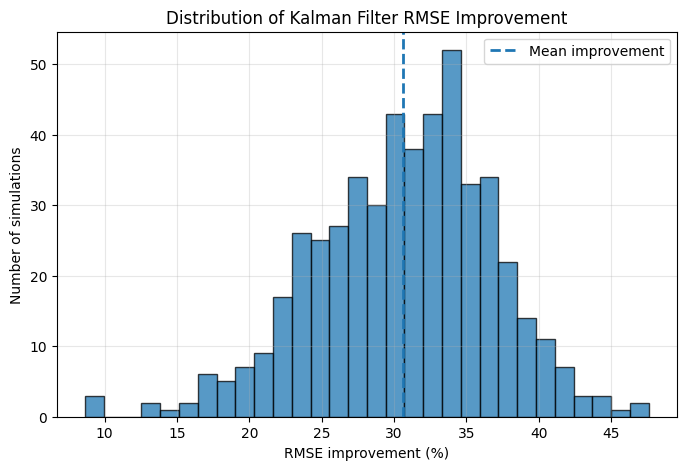

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(
    improvement_results,
    bins=30,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    np.mean(improvement_results),
    linestyle="--",
    linewidth=2,
    label="Mean improvement"
)

plt.xlabel("RMSE improvement (%)")
plt.ylabel("Number of simulations")
plt.title(
    "Distribution of Kalman Filter RMSE Improvement"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [13]:
kalman_wins = np.mean(
    rmse_kalman_results < rmse_obs_results
) * 100

print(
    f"Kalman filter outperformed raw observations "
    f"in {kalman_wins:.1f}% of simulations."
)

Kalman filter outperformed raw observations in 100.0% of simulations.


In [14]:
# ============================================
# Part 1C: NEES Filter Consistency
# ============================================

n_state = x_true.shape[1]

nees = np.zeros(T)

for t in range(T):
    # Actual estimation error
    error = x_true[t] - x_filt[t]

    # Small numerical stabilization
    P = P_filt[t] + 1e-9 * np.eye(n_state)

    # NEES = e' P^-1 e
    nees[t] = error.T @ np.linalg.solve(P, error)

print(f"Mean NEES: {np.mean(nees):.3f}")
print(f"Expected NEES: {n_state}")

Mean NEES: 3.808
Expected NEES: 4


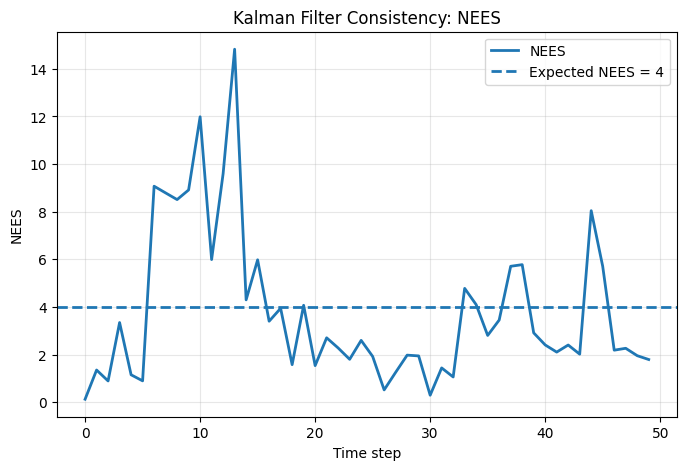

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    nees,
    label="NEES",
    linewidth=2
)

plt.axhline(
    n_state,
    linestyle="--",
    linewidth=2,
    label=f"Expected NEES = {n_state}"
)

plt.xlabel("Time step")
plt.ylabel("NEES")
plt.title("Kalman Filter Consistency: NEES")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [16]:
# ============================================
# Monte Carlo NEES Evaluation
# ============================================

N_SIM = 500

mean_nees_results = np.zeros(N_SIM)

for i in range(N_SIM):

    # Generate trajectory
    x_true_sim, y_obs_sim = simulate_system(
        T, A, H, Q, R, x0_true
    )

    # Run Kalman filter
    _, _, x_filt_sim, P_filt_sim = kalman_filter(
        y_obs_sim,
        A,
        H,
        Q,
        R,
        x0_est,
        P0
    )

    nees_sim = np.zeros(T)

    for t in range(T):

        error = x_true_sim[t] - x_filt_sim[t]

        P = P_filt_sim[t] + 1e-9 * np.eye(n_state)

        nees_sim[t] = (
            error.T
            @ np.linalg.solve(P, error)
        )

    # Average NEES for this simulation
    mean_nees_results[i] = np.mean(nees_sim)

print("Monte Carlo NEES Results")
print("=" * 40)

print(f"Mean NEES:   {np.mean(mean_nees_results):.3f}")
print(f"Median NEES: {np.median(mean_nees_results):.3f}")
print(f"SD of NEES:  {np.std(mean_nees_results):.3f}")
print(f"Expected:    {n_state}")

Monte Carlo NEES Results
Mean NEES:   3.835
Median NEES: 3.751
SD of NEES:  0.694
Expected:    4


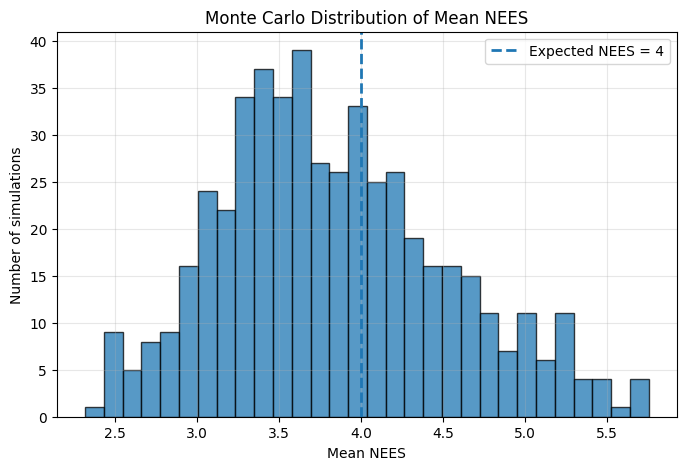

In [17]:
plt.figure(figsize=(8, 5))

plt.hist(
    mean_nees_results,
    bins=30,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    n_state,
    linestyle="--",
    linewidth=2,
    label=f"Expected NEES = {n_state}"
)

plt.xlabel("Mean NEES")
plt.ylabel("Number of simulations")
plt.title("Monte Carlo Distribution of Mean NEES")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [18]:
# ============================================
# Part 2A: Multi-Step Trajectory Forecast
# ============================================

def forecast_state(x_filtered, P_filtered, A, Q, forecast_start, forecast_end):
    """
    Forecast future states using the last filtered
    state without using future observations.
    """
    
    n_state = A.shape[0]
    n_forecast = forecast_end - forecast_start
    
    # Arrays to store forecasts
    x_forecast = np.zeros((n_forecast, n_state))
    P_forecast = np.zeros((n_forecast, n_state, n_state))
    
    # Start with the last available filtered state
    x_current = x_filtered[forecast_start]
    P_current = P_filtered[forecast_start]
    
    for i in range(n_forecast):
        
        # Propagate state forward
        x_current = A @ x_current
        
        # Propagate uncertainty forward
        P_current = A @ P_current @ A.T + Q
        
        # Store forecast
        x_forecast[i] = x_current
        P_forecast[i] = P_current
    
    return x_forecast, P_forecast

In [19]:
# Forecasting setup

forecast_start = 30
forecast_end = T

x_forecast, P_forecast = forecast_state(
    x_filt,
    P_filt,
    A,
    Q,
    forecast_start,
    forecast_end
)

print("Forecast shape:", x_forecast.shape)
print("Forecast covariance shape:", P_forecast.shape)

Forecast shape: (20, 4)
Forecast covariance shape: (20, 4, 4)


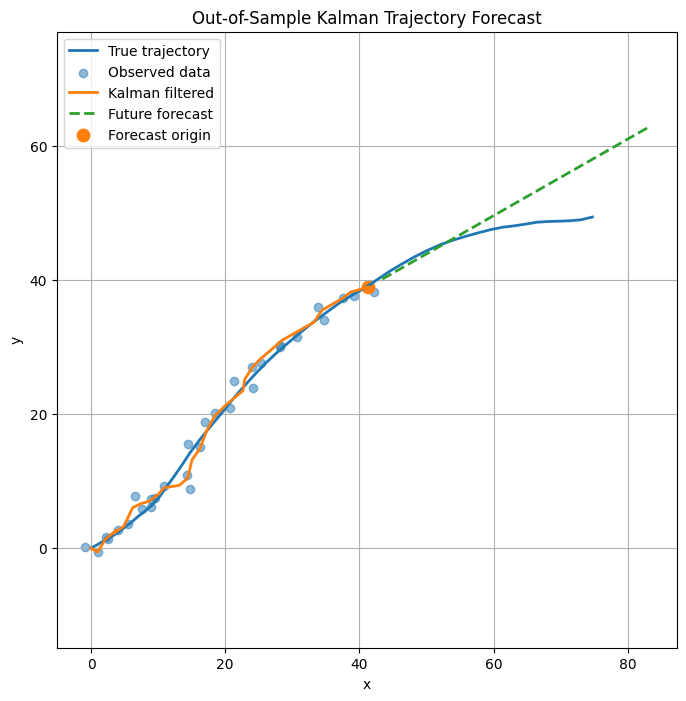

In [20]:
plt.figure(figsize=(8, 8))

# True trajectory
plt.plot(
    x_true[:, 0],
    x_true[:, 1],
    label="True trajectory",
    linewidth=2
)

# Observations available to the model
plt.scatter(
    y_obs[:forecast_start + 1, 0],
    y_obs[:forecast_start + 1, 1],
    alpha=0.5,
    label="Observed data"
)

# Kalman filtered trajectory
plt.plot(
    x_filt[:forecast_start + 1, 0],
    x_filt[:forecast_start + 1, 1],
    linewidth=2,
    label="Kalman filtered"
)

# Forecast
forecast_times = np.arange(
    forecast_start + 1,
    forecast_end
)

plt.plot(
    x_forecast[:, 0],
    x_forecast[:, 1],
    linestyle="--",
    linewidth=2,
    label="Future forecast"
)

# Forecast starting point
plt.scatter(
    x_filt[forecast_start, 0],
    x_filt[forecast_start, 1],
    s=80,
    label="Forecast origin"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Out-of-Sample Kalman Trajectory Forecast")
plt.legend()
plt.axis("equal")
plt.grid(True)

plt.show()

In [22]:
# ============================================
# Part 2A: Multi-Step Trajectory Forecast
# ============================================

def forecast_state(x_filtered, P_filtered, A, Q, forecast_start, forecast_end):
    """
    Forecast future states from forecast_start + 1
    through forecast_end - 1.
    """

    n_state = A.shape[0]
    n_forecast = forecast_end - forecast_start - 1

    x_forecast = np.zeros((n_forecast, n_state))
    P_forecast = np.zeros((n_forecast, n_state, n_state))

    # Start from the final filtered state
    x_current = x_filtered[forecast_start]
    P_current = P_filtered[forecast_start]

    for i in range(n_forecast):

        # Predict one step into the future
        x_current = A @ x_current

        # Propagate uncertainty
        P_current = A @ P_current @ A.T + Q

        x_forecast[i] = x_current
        P_forecast[i] = P_current

    return x_forecast, P_forecast

In [23]:
forecast_start = 30
forecast_end = T

x_forecast, P_forecast = forecast_state(
    x_filt,
    P_filt,
    A,
    Q,
    forecast_start,
    forecast_end
)

print("Forecast shape:", x_forecast.shape)
print("Forecast covariance shape:", P_forecast.shape)

Forecast shape: (19, 4)
Forecast covariance shape: (19, 4, 4)


In [24]:
x_true_future = x_true[forecast_start + 1:forecast_end]

forecast_position = x_forecast[:, :2]

true_position = x_true_future[:, :2]

forecast_error = forecast_position - true_position

forecast_distance_error = np.sqrt(
    np.sum(forecast_error**2, axis=1)
)

forecast_rmse = np.sqrt(
    np.mean(forecast_distance_error**2)
)

forecast_mae = np.mean(
    forecast_distance_error
)

print(f"Forecast RMSE: {forecast_rmse:.3f}")
print(f"Forecast MAE:  {forecast_mae:.3f}")

Forecast RMSE: 6.982
Forecast MAE:  5.549


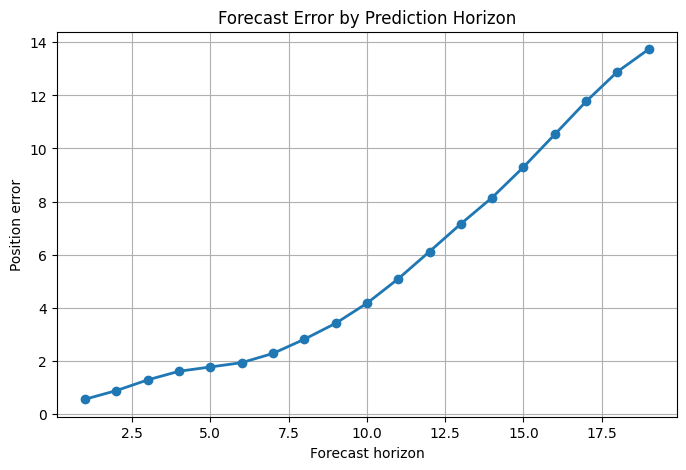

In [25]:
forecast_horizons = np.arange(
    1,
    len(forecast_distance_error) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    forecast_horizons,
    forecast_distance_error,
    marker="o",
    linewidth=2
)

plt.xlabel("Forecast horizon")
plt.ylabel("Position error")
plt.title("Forecast Error by Prediction Horizon")
plt.grid(True)

plt.show()

In [26]:
# ============================================
# Part 3A: Forecast Uncertainty
# ============================================

# Extract position variances
var_x = P_forecast[:, 0, 0]
var_y = P_forecast[:, 1, 1]

# Standard deviations
std_x = np.sqrt(var_x)
std_y = np.sqrt(var_y)

# Approximate 95% marginal prediction intervals
lower_x = x_forecast[:, 0] - 1.96 * std_x
upper_x = x_forecast[:, 0] + 1.96 * std_x

lower_y = x_forecast[:, 1] - 1.96 * std_y
upper_y = x_forecast[:, 1] + 1.96 * std_y

print("First forecast position:")
print(f"x = {x_forecast[0, 0]:.3f}")
print(f"y = {x_forecast[0, 1]:.3f}")

print("\nFirst forecast standard deviations:")
print(f"SD(x) = {std_x[0]:.3f}")
print(f"SD(y) = {std_y[0]:.3f}")

print("\nFinal forecast standard deviations:")
print(f"SD(x) = {std_x[-1]:.3f}")
print(f"SD(y) = {std_y[-1]:.3f}")

First forecast position:
x = 43.427
y = 40.096

First forecast standard deviations:
SD(x) = 0.937
SD(y) = 0.937

Final forecast standard deviations:
SD(x) = 11.680
SD(y) = 11.680


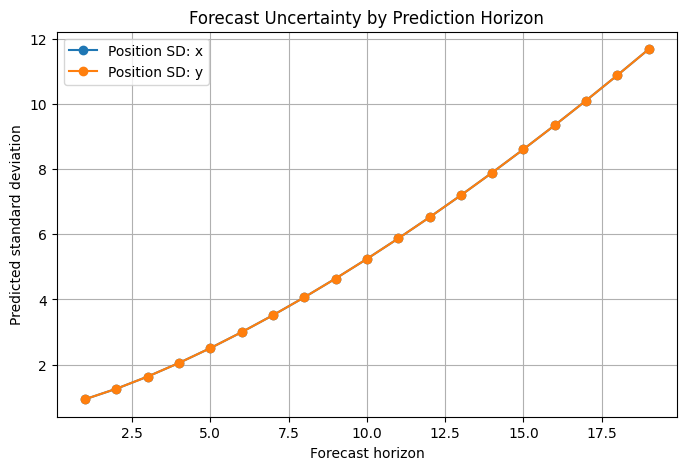

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    forecast_horizons,
    std_x,
    marker="o",
    label="Position SD: x"
)

plt.plot(
    forecast_horizons,
    std_y,
    marker="o",
    label="Position SD: y"
)

plt.xlabel("Forecast horizon")
plt.ylabel("Predicted standard deviation")
plt.title("Forecast Uncertainty by Prediction Horizon")
plt.legend()
plt.grid(True)

plt.show()

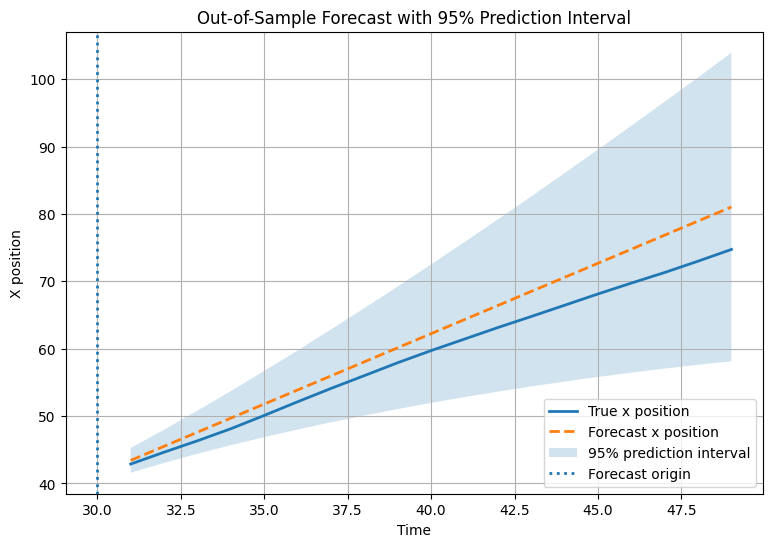

In [28]:
plt.figure(figsize=(9, 6))

forecast_times = np.arange(
    forecast_start + 1,
    forecast_end
)

# True future x position
plt.plot(
    forecast_times,
    x_true[forecast_start + 1:forecast_end, 0],
    label="True x position",
    linewidth=2
)

# Forecasted x position
plt.plot(
    forecast_times,
    x_forecast[:, 0],
    linestyle="--",
    linewidth=2,
    label="Forecast x position"
)

# 95% prediction interval
plt.fill_between(
    forecast_times,
    lower_x,
    upper_x,
    alpha=0.2,
    label="95% prediction interval"
)

plt.axvline(
    forecast_start,
    linestyle=":",
    linewidth=2,
    label="Forecast origin"
)

plt.xlabel("Time")
plt.ylabel("X position")
plt.title("Out-of-Sample Forecast with 95% Prediction Interval")
plt.legend()
plt.grid(True)

plt.show()

In [29]:
# ============================================
# Part 3D: Monte Carlo Probabilistic Forecasting
# ============================================

N_SIM = 500

n_forecast = forecast_end - forecast_start - 1

# Store results
forecast_rmse_results = np.zeros(N_SIM)
forecast_mae_results = np.zeros(N_SIM)

# Store coverage at each forecast horizon
coverage_x = np.zeros((N_SIM, n_forecast))
coverage_y = np.zeros((N_SIM, n_forecast))

# Store forecast error by horizon
forecast_error_by_horizon = np.zeros(
    (N_SIM, n_forecast)
)

for i in range(N_SIM):

    # ----------------------------------------
    # 1. Generate new trajectory
    # ----------------------------------------
    x_true_sim, y_obs_sim = simulate_system(
        T, A, H, Q, R, x0_true
    )

    # ----------------------------------------
    # 2. Run Kalman filter
    # ----------------------------------------
    _, _, x_filt_sim, P_filt_sim = kalman_filter(
        y_obs_sim,
        A,
        H,
        Q,
        R,
        x0_est,
        P0
    )

    # ----------------------------------------
    # 3. Forecast future states
    # ----------------------------------------
    x_forecast_sim, P_forecast_sim = forecast_state(
        x_filt_sim,
        P_filt_sim,
        A,
        Q,
        forecast_start,
        forecast_end
    )

    # ----------------------------------------
    # 4. True future positions
    # ----------------------------------------
    x_true_future_sim = x_true_sim[
        forecast_start + 1:forecast_end
    ]

    # ----------------------------------------
    # 5. Position forecast error
    # ----------------------------------------
    error = (
        x_forecast_sim[:, :2]
        - x_true_future_sim[:, :2]
    )

    distance_error = np.sqrt(
        np.sum(error**2, axis=1)
    )

    # Store horizon-specific errors
    forecast_error_by_horizon[i] = distance_error

    # ----------------------------------------
    # 6. Overall RMSE and MAE
    # ----------------------------------------
    forecast_rmse_results[i] = np.sqrt(
        np.mean(distance_error**2)
    )

    forecast_mae_results[i] = np.mean(
        distance_error
    )

    # ----------------------------------------
    # 7. Calculate prediction intervals
    # ----------------------------------------
    std_x_sim = np.sqrt(
        P_forecast_sim[:, 0, 0]
    )

    std_y_sim = np.sqrt(
        P_forecast_sim[:, 1, 1]
    )

    lower_x_sim = (
        x_forecast_sim[:, 0]
        - 1.96 * std_x_sim
    )

    upper_x_sim = (
        x_forecast_sim[:, 0]
        + 1.96 * std_x_sim
    )

    lower_y_sim = (
        x_forecast_sim[:, 1]
        - 1.96 * std_y_sim
    )

    upper_y_sim = (
        x_forecast_sim[:, 1]
        + 1.96 * std_y_sim
    )

    # ----------------------------------------
    # 8. Check interval coverage
    # ----------------------------------------
    coverage_x[i] = (
        (x_true_future_sim[:, 0] >= lower_x_sim)
        &
        (x_true_future_sim[:, 0] <= upper_x_sim)
    )

    coverage_y[i] = (
        (x_true_future_sim[:, 1] >= lower_y_sim)
        &
        (x_true_future_sim[:, 1] <= upper_y_sim)
    )

In [30]:
# ============================================
# Monte Carlo Forecast Summary
# ============================================

print("Monte Carlo Forecast Results")
print("=" * 40)

print(
    f"Mean forecast RMSE: "
    f"{np.mean(forecast_rmse_results):.3f}"
)

print(
    f"Median forecast RMSE: "
    f"{np.median(forecast_rmse_results):.3f}"
)

print(
    f"Mean forecast MAE: "
    f"{np.mean(forecast_mae_results):.3f}"
)

print(
    f"Median forecast MAE: "
    f"{np.median(forecast_mae_results):.3f}"
)

Monte Carlo Forecast Results
Mean forecast RMSE: 8.387
Median forecast RMSE: 7.876
Mean forecast MAE: 7.132
Median forecast MAE: 6.712


In [31]:
# ============================================
# Prediction Interval Coverage
# ============================================

coverage_x_rate = np.mean(
    coverage_x,
    axis=0
) * 100

coverage_y_rate = np.mean(
    coverage_y,
    axis=0
) * 100

forecast_horizons = np.arange(
    1,
    n_forecast + 1
)

print("\n95% Prediction Interval Coverage")
print("=" * 40)

for h in range(n_forecast):

    print(
        f"Horizon {h + 1:2d}: "
        f"X = {coverage_x_rate[h]:5.1f}% | "
        f"Y = {coverage_y_rate[h]:5.1f}%"
    )


95% Prediction Interval Coverage
Horizon  1: X =  94.8% | Y =  95.2%
Horizon  2: X =  94.6% | Y =  95.4%
Horizon  3: X =  95.0% | Y =  95.8%
Horizon  4: X =  94.6% | Y =  96.2%
Horizon  5: X =  94.8% | Y =  96.4%
Horizon  6: X =  94.4% | Y =  96.0%
Horizon  7: X =  94.0% | Y =  95.6%
Horizon  8: X =  93.4% | Y =  95.4%
Horizon  9: X =  94.4% | Y =  94.8%
Horizon 10: X =  94.2% | Y =  94.4%
Horizon 11: X =  94.0% | Y =  94.8%
Horizon 12: X =  93.8% | Y =  95.2%
Horizon 13: X =  94.2% | Y =  95.2%
Horizon 14: X =  94.0% | Y =  94.8%
Horizon 15: X =  94.0% | Y =  94.4%
Horizon 16: X =  94.0% | Y =  95.0%
Horizon 17: X =  93.8% | Y =  95.4%
Horizon 18: X =  94.0% | Y =  95.4%
Horizon 19: X =  94.4% | Y =  95.0%


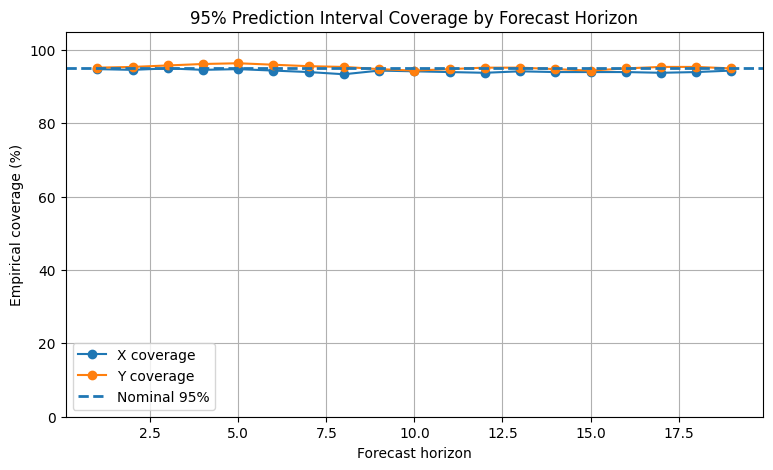

In [32]:
plt.figure(figsize=(9, 5))

plt.plot(
    forecast_horizons,
    coverage_x_rate,
    marker="o",
    label="X coverage"
)

plt.plot(
    forecast_horizons,
    coverage_y_rate,
    marker="o",
    label="Y coverage"
)

plt.axhline(
    95,
    linestyle="--",
    linewidth=2,
    label="Nominal 95%"
)

plt.xlabel("Forecast horizon")
plt.ylabel("Empirical coverage (%)")
plt.title(
    "95% Prediction Interval Coverage by Forecast Horizon"
)

plt.ylim(0, 105)
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#Real world microsoft GPS data 

In [2]:
import os

print(os.getcwd())

C:\Users\landr


In [4]:
from pathlib import Path

downloads = Path(r"C:\Users\landr\Downloads")

zip_files = list(downloads.glob("*.zip"))

for file in zip_files:
    print(file)

C:\Users\landr\Downloads\archive.zip
C:\Users\landr\Downloads\attachments.zip
C:\Users\landr\Downloads\Cell_20231223.zip
C:\Users\landr\Downloads\Cell_20240307.zip
C:\Users\landr\Downloads\Geolife Trajectories 1.3.zip
C:\Users\landr\Downloads\heart.data_.zip
C:\Users\landr\Downloads\libtorch-win-shared-with-deps-2.8.0+cu126.zip
C:\Users\landr\Downloads\Neuroscience_20240304.zip
C:\Users\landr\Downloads\payslip.zip
C:\Users\landr\Downloads\plays.csv.zip
C:\Users\landr\Downloads\Rdpack_2.6.4 (1).zip
C:\Users\landr\Downloads\Rdpack_2.6.4.zip
C:\Users\landr\Downloads\Re_ PowerPoint from previous class.zip
C:\Users\landr\Downloads\sqlite-src-3500400.zip
C:\Users\landr\Downloads\statsFilesLandry.zip
C:\Users\landr\Downloads\stroopAdvanced.zip
C:\Users\landr\Downloads\The _big thing_ for your thesis -- Bayes factor design analysis.zip
C:\Users\landr\Downloads\thekubesphotoshoot-photo-download-1of1.zip
C:\Users\landr\Downloads\TurboTax_Deluxe_2023_Tax_Software_Federal_Tax_Return_Amazon_Exclusi

In [5]:
from pathlib import Path

zip_path = Path(r"C:\Users\landr\Downloads\Geolife Trajectories 1.3.zip")

print("File exists:", zip_path.exists())
print("File path:", zip_path)

File exists: True
File path: C:\Users\landr\Downloads\Geolife Trajectories 1.3.zip


In [6]:
import zipfile
import pandas as pd
import numpy as np

trajectory_path = (
    "Geolife Trajectories 1.3/Data/065/Trajectory/"
    "20111025085403.plt"
)

with zipfile.ZipFile(zip_path, "r") as z:
    
    with z.open(trajectory_path) as file:
        
        df = pd.read_csv(
            file,
            skiprows=6,
            header=None,
            names=[
                "latitude",
                "longitude",
                "unused",
                "altitude",
                "date_serial",
                "date",
                "time"
            ]
        )

df.head()

,latitude,longitude,unused,altitude,date_serial,date,time
0,39.980867,116.307328,0,0,40841.370868,2011-10-25,08:54:03
1,39.980863,116.307283,0,0,40841.370880,2011-10-25,08:54:04
2,39.981077,116.307423,0,0,40841.371100,2011-10-25,08:54:23
3,39.981112,116.307445,0,0,40841.371111,2011-10-25,08:54:24
4,39.981117,116.307447,0,0,40841.371111,2011-10-25,08:54:24


In [7]:
# Combine date and time into one datetime variable
df["datetime"] = pd.to_datetime(
    df["date"] + " " + df["time"]
)

# Sort chronologically
df = df.sort_values("datetime").reset_index(drop=True)

# Look at the first few observations
df.head()

,latitude,longitude,unused,altitude,date_serial,date,time,datetime
0,39.980867,116.307328,0,0,40841.370868,2011-10-25,08:54:03,2011-10-25 08:54:03
1,39.980863,116.307283,0,0,40841.370880,2011-10-25,08:54:04,2011-10-25 08:54:04
2,39.981077,116.307423,0,0,40841.371100,2011-10-25,08:54:23,2011-10-25 08:54:23
3,39.981112,116.307445,0,0,40841.371111,2011-10-25,08:54:24,2011-10-25 08:54:24
4,39.981117,116.307447,0,0,40841.371111,2011-10-25,08:54:24,2011-10-25 08:54:24


In [8]:
print("Number of observations:", len(df))

print("\nMissing values:")
print(df.isnull().sum())

print("\nStart time:", df["datetime"].min())
print("End time:", df["datetime"].max())

print("\nTotal duration:")
print(df["datetime"].max() - df["datetime"].min())

Number of observations: 9901

Missing values:
latitude       0
longitude      0
unused         0
altitude       0
date_serial    0
date           0
time           0
datetime       0
dtype: int64

Start time: 2011-10-25 08:54:03
End time: 2011-10-25 10:18:16

Total duration:
0 days 01:24:13


In [9]:
df["dt"] = df["datetime"].diff().dt.total_seconds()

print(df["dt"].describe())

count    9900.000000
mean        0.510404
std        14.250681
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      1320.000000
Name: dt, dtype: float64


In [10]:
print("\nMost common time intervals:")
print(df["dt"].value_counts().head(10))


Most common time intervals:
dt
0.0     7842
1.0     1993
8.0       12
12.0       5
11.0       5
9.0        4
10.0       4
18.0       3
13.0       3
19.0       2
Name: count, dtype: int64


In [11]:
print("Duplicate timestamps:", df["datetime"].duplicated().sum())

print("\nFirst rows with duplicate timestamps:")
duplicates = df[df["datetime"].duplicated(keep=False)]

duplicates[["latitude", "longitude", "datetime"]].head(20)

Duplicate timestamps: 7842

First rows with duplicate timestamps:


,latitude,longitude,datetime
3,39.981112,116.307445,2011-10-25 08:54:24
4,39.981117,116.307447,2011-10-25 08:54:24
5,39.981107,116.307445,2011-10-25 08:54:24
6,39.981097,116.307437,2011-10-25 08:54:24
7,39.981103,116.307448,2011-10-25 08:54:24
8,39.981130,116.307463,2011-10-25 08:54:25
9,39.981135,116.307470,2011-10-25 08:54:25
10,39.981127,116.307458,2011-10-25 08:54:25
11,39.981118,116.307447,2011-10-25 08:54:25
12,39.981122,116.307448,2011-10-25 08:54:25


In [12]:
# Look at consecutive observations where dt = 0
df.loc[
    df["dt"] == 0,
    ["latitude", "longitude", "datetime", "dt"]
].head(20)

,latitude,longitude,datetime,dt
4,39.981117,116.307447,2011-10-25 08:54:24,0.0
5,39.981107,116.307445,2011-10-25 08:54:24,0.0
6,39.981097,116.307437,2011-10-25 08:54:24,0.0
7,39.981103,116.307448,2011-10-25 08:54:24,0.0
9,39.981135,116.307470,2011-10-25 08:54:25,0.0
10,39.981127,116.307458,2011-10-25 08:54:25,0.0
11,39.981118,116.307447,2011-10-25 08:54:25,0.0
12,39.981122,116.307448,2011-10-25 08:54:25,0.0
14,39.981155,116.307493,2011-10-25 08:54:26,0.0
15,39.981148,116.307485,2011-10-25 08:54:26,0.0


In [13]:
# Average all GPS measurements that occur within the same second

df_clean = (
    df.groupby("datetime", as_index=False)
      .agg({
          "latitude": "mean",
          "longitude": "mean",
          "altitude": "mean"
      })
)

print("Original observations:", len(df))
print("Observations after aggregation:", len(df_clean))

df_clean.head(10)

Original observations: 9901
Observations after aggregation: 2059


,datetime,latitude,longitude,altitude
0,2011-10-25 08:54:03,39.980867,116.307328,0.0
1,2011-10-25 08:54:04,39.980863,116.307283,0.0
2,2011-10-25 08:54:23,39.981077,116.307423,0.0
3,2011-10-25 08:54:24,39.981107,116.307444,0.0
4,2011-10-25 08:54:25,39.981126,116.307457,0.0
5,2011-10-25 08:54:26,39.981156,116.307493,0.0
6,2011-10-25 08:54:27,39.981189,116.307520,0.0
7,2011-10-25 08:54:28,39.981213,116.307527,0.0
8,2011-10-25 08:54:29,39.981228,116.307557,0.0
9,2011-10-25 08:54:30,39.981227,116.307562,0.0


In [14]:
df_clean["dt"] = (
    df_clean["datetime"]
    .diff()
    .dt
    .total_seconds()
)

print(df_clean["dt"].describe())

print("\nMost common intervals:")
print(df_clean["dt"].value_counts().head(10))

count    2058.000000
mean        2.455296
std        31.185306
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max      1320.000000
Name: dt, dtype: float64

Most common intervals:
dt
1.0     1993
8.0       12
11.0       5
12.0       5
9.0        4
10.0       4
18.0       3
13.0       3
15.0       2
16.0       2
Name: count, dtype: int64


In [15]:
import numpy as np

# Earth's approximate radius in metres
R_earth = 6_371_000

# Use the first GPS point as our local origin
lat0 = np.radians(df_clean["latitude"].iloc[0])
lon0 = np.radians(df_clean["longitude"].iloc[0])

# Convert latitude and longitude to radians
lat = np.radians(df_clean["latitude"])
lon = np.radians(df_clean["longitude"])

# Convert to local Cartesian coordinates in metres
df_clean["x"] = R_earth * (lon - lon0) * np.cos(lat0)
df_clean["y"] = R_earth * (lat - lat0)

df_clean[["latitude", "longitude", "x", "y"]].head()

,latitude,longitude,x,y
0,39.980867,116.307328,0.000000,0.000000
1,39.980863,116.307283,-3.834185,-0.370650
2,39.981077,116.307423,8.094391,23.350935
3,39.981107,116.307444,9.883678,26.723847
4,39.981126,116.307457,10.991331,28.873616


In [16]:
print("X range (metres):")
print(df_clean["x"].min(), "to", df_clean["x"].max())

print("\nY range (metres):")
print(df_clean["y"].min(), "to", df_clean["y"].max())

X range (metres):
-15.223135916612561 to 1739.6409021699783

Y range (metres):
-1849.1716300990438 to 2439.9873403331594


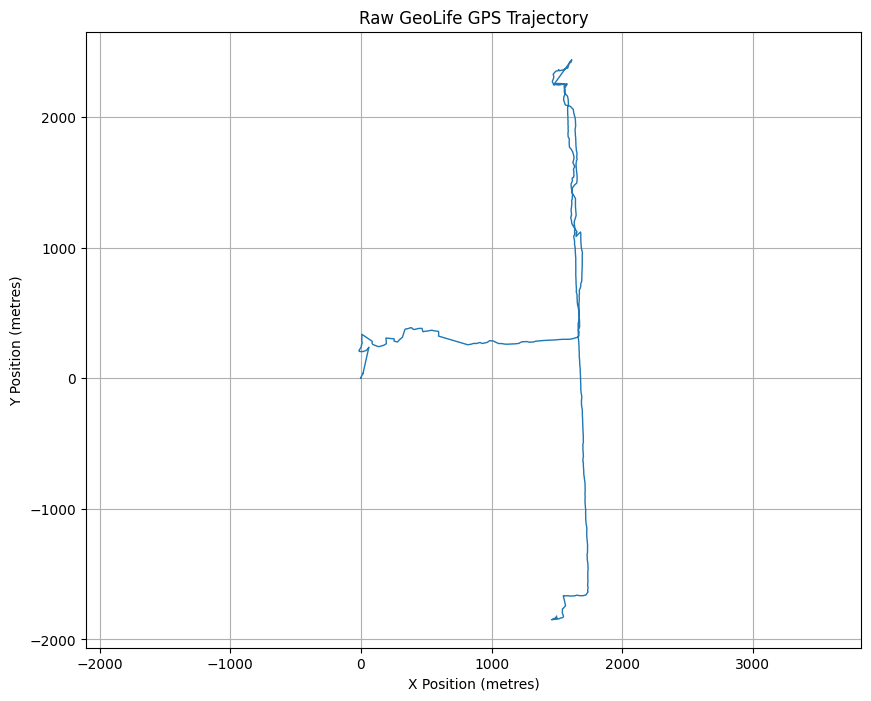

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.plot(
    df_clean["x"],
    df_clean["y"],
    linewidth=1
)

plt.xlabel("X Position (metres)")
plt.ylabel("Y Position (metres)")
plt.title("Raw GeoLife GPS Trajectory")

plt.axis("equal")
plt.grid(True)

plt.show()

In [19]:
H = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0]
])

In [20]:
# Measurement matrix: GPS observes position only
H = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0]
])

# Measurement noise covariance
# Starting assumption: GPS measurement uncertainty
sigma_gps = 5.0  # metres

R = np.array([
    [sigma_gps**2, 0],
    [0, sigma_gps**2]
])

# Process noise parameter
# Controls how much we allow acceleration / movement changes
sigma_a = 1.0

In [21]:
def get_matrices(dt, sigma_a):
    
    # State transition matrix
    A = np.array([
        [1, 0, dt, 0],
        [0, 1, 0, dt],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])
    
    # Process noise covariance matrix
    q = sigma_a**2
    
    Q = q * np.array([
        [dt**4 / 4, 0,           dt**3 / 2, 0],
        [0,           dt**4 / 4, 0,           dt**3 / 2],
        [dt**3 / 2, 0,           dt**2,       0],
        [0,           dt**3 / 2, 0,           dt**2]
    ])
    
    return A, Q

In [22]:
# Initial time difference
dt0 = df_clean["dt"].iloc[1]

# Initial velocity estimate
vx0 = (
    df_clean["x"].iloc[1] -
    df_clean["x"].iloc[0]
) / dt0

vy0 = (
    df_clean["y"].iloc[1] -
    df_clean["y"].iloc[0]
) / dt0

# Initial state
x_state = np.array([
    df_clean["x"].iloc[0],
    df_clean["y"].iloc[0],
    vx0,
    vy0
])

# Initial uncertainty
P = np.diag([
    25,   # x uncertainty
    25,   # y uncertainty
    100,  # vx uncertainty
    100   # vy uncertainty
])

print("Initial state:")
print(x_state)

Initial state:
[ 0.          0.         -3.83418536 -0.37064976]


In [23]:
filtered_states = []

for i in range(1, len(df_clean)):
    
    # Actual elapsed time
    dt = df_clean["dt"].iloc[i]
    
    # Get dynamic transition and process-noise matrices
    A, Q = get_matrices(dt, sigma_a)
    
    # --------------------
    # PREDICT
    # --------------------
    
    x_pred = A @ x_state
    
    P_pred = A @ P @ A.T + Q
    
    # GPS observation
    z = np.array([
        df_clean["x"].iloc[i],
        df_clean["y"].iloc[i]
    ])
    
    # --------------------
    # UPDATE
    # --------------------
    
    innovation = z - H @ x_pred
    
    S = H @ P_pred @ H.T + R
    
    K = P_pred @ H.T @ np.linalg.inv(S)
    
    x_state = x_pred + K @ innovation
    
    P = (np.eye(4) - K @ H) @ P_pred
    
    filtered_states.append(x_state.copy())

filtered_states = np.array(filtered_states)

print("Filtering complete!")
print("Filtered states shape:", filtered_states.shape)

Filtering complete!
Filtered states shape: (2058, 4)


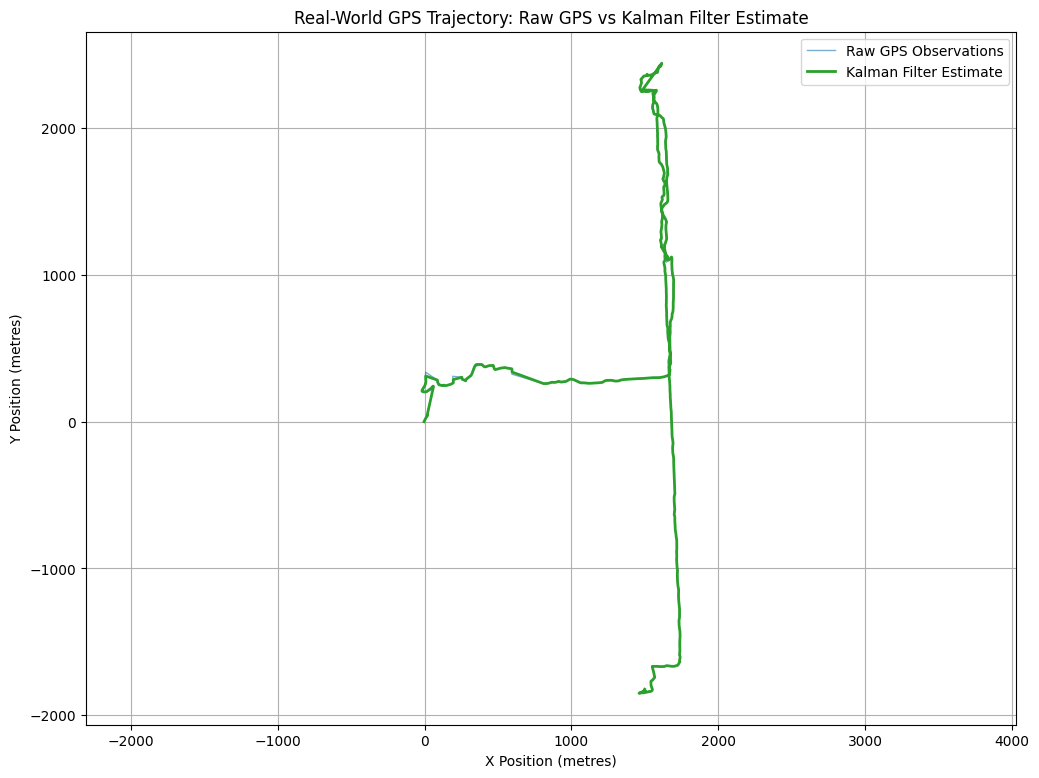

In [24]:
plt.figure(figsize=(12, 9))

plt.plot(
    df_clean["x"],
    df_clean["y"],
    label="Raw GPS Observations",
    alpha=0.6,
    linewidth=1
)

plt.plot(
    df_clean["x"].iloc[1:],
    df_clean["y"].iloc[1:],
    alpha=0  # invisible alignment reference
)

plt.plot(
    filtered_states[:, 0],
    filtered_states[:, 1],
    label="Kalman Filter Estimate",
    linewidth=2
)

plt.xlabel("X Position (metres)")
plt.ylabel("Y Position (metres)")
plt.title("Real-World GPS Trajectory: Raw GPS vs Kalman Filter Estimate")

plt.legend()
plt.axis("equal")
plt.grid(True)

plt.show()

In [25]:
# Align raw observations with filtered states
raw_x = df_clean["x"].iloc[1:].to_numpy()
raw_y = df_clean["y"].iloc[1:].to_numpy()

# Distance between raw GPS and Kalman estimate
difference = np.sqrt(
    (filtered_states[:, 0] - raw_x)**2 +
    (filtered_states[:, 1] - raw_y)**2
)

print("Mean difference:", difference.mean(), "metres")
print("Median difference:", np.median(difference), "metres")
print("Maximum difference:", difference.max(), "metres")

Mean difference: 1.0577078758277647 metres
Median difference: 0.5584852685299685 metres
Maximum difference: 26.632650344374156 metres


In [26]:
# Create a copy for evaluation
df_eval = df_clean.iloc[1:].copy().reset_index(drop=True)

# Add Kalman Filter state estimates
df_eval["kf_x"] = filtered_states[:, 0]
df_eval["kf_y"] = filtered_states[:, 1]
df_eval["kf_vx"] = filtered_states[:, 2]
df_eval["kf_vy"] = filtered_states[:, 3]

df_eval.head()

,datetime,latitude,longitude,altitude,dt,x,y,kf_x,kf_y,kf_vx,kf_vy
0,2011-10-25 08:54:04,39.980863,116.307283,0.0,1.0,-3.834185,-0.370650,-3.834185,-0.370650,-3.834185,-0.370650
1,2011-10-25 08:54:23,39.981077,116.307423,0.0,19.0,8.094391,23.350935,8.047764,23.334015,3.790308,2.396095
2,2011-10-25 08:54:24,39.981107,116.307444,0.0,1.0,9.883678,26.723847,10.480562,26.420354,3.077065,2.758753
3,2011-10-25 08:54:25,39.981126,116.307457,0.0,1.0,10.991331,28.873616,11.812966,28.971423,2.194740,2.653721
4,2011-10-25 08:54:26,39.981156,116.307493,0.0,1.0,14.030278,32.135334,14.022032,31.948941,2.200707,2.788581


In [27]:
def rolling_forecast_evaluation(df, horizons):
    
    results = []
    
    times = df["datetime"].to_numpy()
    
    for horizon in horizons:
        
        errors = []
        actual_horizons = []
        
        for i in range(len(df) - 1):
            
            # Current state estimate
            x0 = df["kf_x"].iloc[i]
            y0 = df["kf_y"].iloc[i]
            
            vx = df["kf_vx"].iloc[i]
            vy = df["kf_vy"].iloc[i]
            
            current_time = df["datetime"].iloc[i]
            target_time = current_time + pd.Timedelta(seconds=horizon)
            
            # Find first observation at or after target time
            future_indices = np.where(
                df["datetime"].to_numpy() >= target_time
            )[0]
            
            # Keep only observations after the current point
            future_indices = future_indices[future_indices > i]
            
            if len(future_indices) == 0:
                continue
            
            j = future_indices[0]
            
            # Actual elapsed time
            actual_dt = (
                df["datetime"].iloc[j] -
                current_time
            ).total_seconds()
            
            # Forecast position using constant velocity
            x_forecast = x0 + vx * actual_dt
            y_forecast = y0 + vy * actual_dt
            
            # Actual future GPS position
            x_actual = df["x"].iloc[j]
            y_actual = df["y"].iloc[j]
            
            # Euclidean forecast error
            error = np.sqrt(
                (x_forecast - x_actual)**2 +
                (y_forecast - y_actual)**2
            )
            
            errors.append(error)
            actual_horizons.append(actual_dt)
        
        errors = np.array(errors)
        
        results.append({
            "Requested Horizon (s)": horizon,
            "Mean Actual Horizon (s)": np.mean(actual_horizons),
            "MAE (m)": np.mean(errors),
            "RMSE (m)": np.sqrt(np.mean(errors**2)),
            "Median Error (m)": np.median(errors),
            "Max Error (m)": np.max(errors),
            "Number of Forecasts": len(errors)
        })
    
    return pd.DataFrame(results)

In [28]:
horizons = [1, 5, 10, 20, 30, 60]

forecast_results = rolling_forecast_evaluation(
    df_eval,
    horizons
)

forecast_results

,Requested Horizon (s),Mean Actual Horizon (s),MAE (m),RMSE (m),Median Error (m),Max Error (m),Number of Forecasts
0,1,2.456004,3.922352,25.108389,1.169981,969.545533,2057
1,5,9.276616,12.534788,36.840908,4.456816,969.545533,2057
2,10,17.052990,22.705252,50.074331,10.349847,969.545533,2057
3,20,30.457462,41.657064,75.144361,23.330575,969.545533,2057
4,30,43.281964,60.918881,98.894916,36.862134,969.545533,2057
5,60,85.653865,137.484799,253.502999,81.535590,4242.249340,2057


In [29]:
print(forecast_results.to_string(index=False))

 Requested Horizon (s)  Mean Actual Horizon (s)    MAE (m)   RMSE (m)  Median Error (m)  Max Error (m)  Number of Forecasts
                     1                 2.456004   3.922352  25.108389          1.169981     969.545533                 2057
                     5                 9.276616  12.534788  36.840908          4.456816     969.545533                 2057
                    10                17.052990  22.705252  50.074331         10.349847     969.545533                 2057
                    20                30.457462  41.657064  75.144361         23.330575     969.545533                 2057
                    30                43.281964  60.918881  98.894916         36.862134     969.545533                 2057
                    60                85.653865 137.484799 253.502999         81.535590    4242.249340                 2057


In [30]:
def rolling_forecast_strict(df, horizons, tolerances):
    
    results = []
    detailed_results = {}
    
    # Convert timestamps to numpy array for faster searching
    times = df["datetime"].to_numpy()
    
    for horizon in horizons:
        
        tolerance = tolerances[horizon]
        
        errors = []
        actual_horizons = []
        forecast_records = []
        
        for i in range(len(df) - 1):
            
            current_time = df["datetime"].iloc[i]
            target_time = current_time + pd.Timedelta(seconds=horizon)
            
            # Find the timestamp closest to our target time
            future_times = df["datetime"].iloc[i + 1:]
            
            if len(future_times) == 0:
                continue
            
            time_differences = np.abs(
                (future_times - target_time).dt.total_seconds()
            )
            
            # Find closest future observation
            closest_position = time_differences.idxmin()
            closest_difference = time_differences.loc[closest_position]
            
            # Only use it if it's within our tolerance window
            if closest_difference > tolerance:
                continue
            
            j = closest_position
            
            # Actual elapsed time
            actual_dt = (
                df["datetime"].iloc[j] -
                current_time
            ).total_seconds()
            
            # Current Kalman state
            x0 = df["kf_x"].iloc[i]
            y0 = df["kf_y"].iloc[i]
            vx = df["kf_vx"].iloc[i]
            vy = df["kf_vy"].iloc[i]
            
            # Constant-velocity forecast
            x_forecast = x0 + vx * actual_dt
            y_forecast = y0 + vy * actual_dt
            
            # Actual future GPS observation
            x_actual = df["x"].iloc[j]
            y_actual = df["y"].iloc[j]
            
            # Euclidean forecast error
            error = np.sqrt(
                (x_forecast - x_actual)**2 +
                (y_forecast - y_actual)**2
            )
            
            errors.append(error)
            actual_horizons.append(actual_dt)
            
            # Save details for failure analysis later
            forecast_records.append({
                "start_index": i,
                "end_index": j,
                "start_time": current_time,
                "end_time": df["datetime"].iloc[j],
                "actual_horizon": actual_dt,
                "forecast_error": error,
                "x_forecast": x_forecast,
                "y_forecast": y_forecast,
                "x_actual": x_actual,
                "y_actual": y_actual
            })
        
        errors = np.array(errors)
        
        # Save detailed results
        detailed_results[horizon] = pd.DataFrame(forecast_records)
        
        results.append({
            "Requested Horizon (s)": horizon,
            "Tolerance (s)": tolerance,
            "Mean Actual Horizon (s)": np.mean(actual_horizons),
            "MAE (m)": np.mean(errors),
            "RMSE (m)": np.sqrt(np.mean(errors**2)),
            "Median Error (m)": np.median(errors),
            "Max Error (m)": np.max(errors),
            "Number of Forecasts": len(errors)
        })
    
    return pd.DataFrame(results), detailed_results

In [31]:
horizons = [1, 5, 10, 20, 30, 60]

tolerances = {
    1: 0.5,
    5: 1,
    10: 1,
    20: 2,
    30: 3,
    60: 5
}

In [32]:
strict_results, detailed_forecasts = rolling_forecast_strict(
    df_eval,
    horizons,
    tolerances
)

print(strict_results.to_string(index=False))

 Requested Horizon (s)  Tolerance (s)  Mean Actual Horizon (s)   MAE (m)   RMSE (m)  Median Error (m)  Max Error (m)  Number of Forecasts
                     1            0.5                 1.000000  2.100338   4.158411          1.113727      49.998230                 1992
                     5            1.0                 4.968009  6.561414  11.025392          3.672236     119.158077                 1813
                    10            1.0                 9.981898 13.109766  21.130019          7.385639     136.465917                 1602
                    20            2.0                19.988586 28.952486  47.718107         17.242812     487.140633                 1577
                    30            3.0                29.972646 43.746580  69.117396         30.299032     671.372671                 1572
                    60            5.0                59.937017 97.900354 138.780226         71.823105    1294.171493                 1683


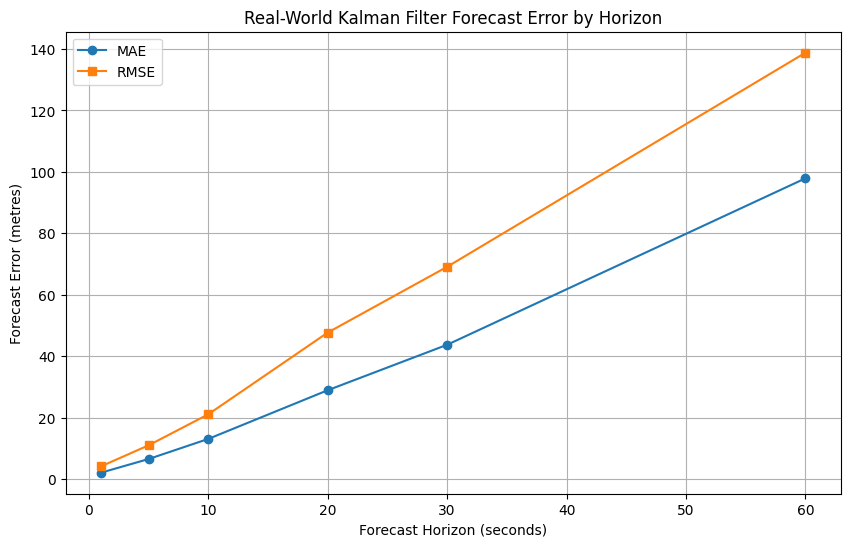

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(
    strict_results["Requested Horizon (s)"],
    strict_results["MAE (m)"],
    marker="o",
    label="MAE"
)

plt.plot(
    strict_results["Requested Horizon (s)"],
    strict_results["RMSE (m)"],
    marker="s",
    label="RMSE"
)

plt.xlabel("Forecast Horizon (seconds)")
plt.ylabel("Forecast Error (metres)")
plt.title("Real-World Kalman Filter Forecast Error by Horizon")

plt.legend()
plt.grid(True)

plt.show()

In [34]:
worst_60 = (
    detailed_forecasts[60]
    .sort_values("forecast_error", ascending=False)
    .head(10)
)

print(worst_60.to_string(index=False))

 start_index  end_index          start_time            end_time  actual_horizon  forecast_error  x_forecast  y_forecast    x_actual    y_actual
          13         44 2011-10-25 08:54:52 2011-10-25 08:55:53            61.0     1294.171493  368.648699 1545.915063   87.014707  282.759432
          14         44 2011-10-25 08:54:53 2011-10-25 08:55:53            60.0     1045.839583  284.191880 1309.843458   87.014707  282.759432
          85        132 2011-10-25 08:57:26 2011-10-25 08:58:30            64.0      865.671414  748.875499 1211.171040  593.446690  359.567328
          84        131 2011-10-25 08:57:25 2011-10-25 08:58:20            55.0      789.061398  701.495895 1140.260493  564.193276  363.236760
          83        131 2011-10-25 08:57:24 2011-10-25 08:58:20            56.0      724.427756  700.324150 1074.759043  564.193276  363.236760
         476        536 2011-10-25 09:07:00 2011-10-25 09:08:00            60.0      717.365352 1208.734211 1848.160676 1612.487955 1255

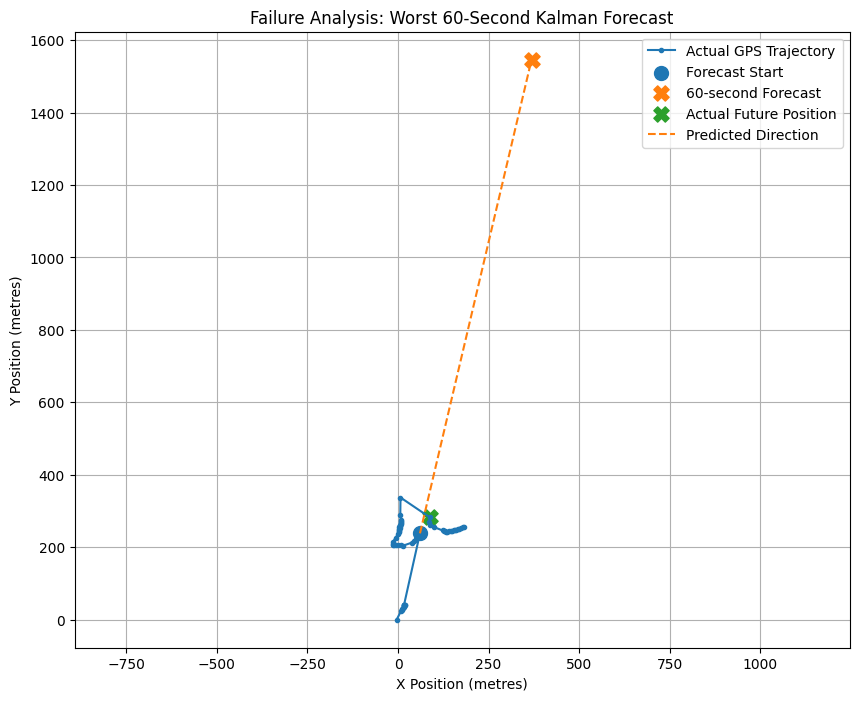

In [35]:
# Get the worst 60-second forecast
worst = detailed_forecasts[60].sort_values(
    "forecast_error",
    ascending=False
).iloc[0]

start_idx = int(worst["start_index"])
end_idx = int(worst["end_index"])

# Create a window around the failure
window_start = max(0, start_idx - 20)
window_end = min(len(df_eval), end_idx + 20)

trajectory_window = df_eval.iloc[window_start:window_end]

plt.figure(figsize=(10, 8))

# Actual trajectory around the failure
plt.plot(
    trajectory_window["x"],
    trajectory_window["y"],
    marker="o",
    markersize=3,
    label="Actual GPS Trajectory"
)

# Starting position
plt.scatter(
    df_eval["x"].iloc[start_idx],
    df_eval["y"].iloc[start_idx],
    s=100,
    marker="o",
    label="Forecast Start"
)

# Forecast position
plt.scatter(
    worst["x_forecast"],
    worst["y_forecast"],
    s=120,
    marker="X",
    label="60-second Forecast"
)

# Actual future position
plt.scatter(
    worst["x_actual"],
    worst["y_actual"],
    s=120,
    marker="X",
    label="Actual Future Position"
)

# Connect forecast start to predicted position
plt.plot(
    [df_eval["x"].iloc[start_idx], worst["x_forecast"]],
    [df_eval["y"].iloc[start_idx], worst["y_forecast"]],
    linestyle="--",
    label="Predicted Direction"
)

plt.xlabel("X Position (metres)")
plt.ylabel("Y Position (metres)")
plt.title("Failure Analysis: Worst 60-Second Kalman Forecast")

plt.legend()
plt.axis("equal")
plt.grid(True)

plt.show()

In [36]:
# Worst 60-second forecast
worst = detailed_forecasts[60].sort_values(
    "forecast_error",
    ascending=False
).iloc[0]

start_idx = int(worst["start_index"])

print("Forecast start time:")
print(df_eval["datetime"].iloc[start_idx])

print("\nKalman Filter state at forecast start:")
print("X position:", df_eval["kf_x"].iloc[start_idx])
print("Y position:", df_eval["kf_y"].iloc[start_idx])
print("Vx:", df_eval["kf_vx"].iloc[start_idx], "m/s")
print("Vy:", df_eval["kf_vy"].iloc[start_idx], "m/s")

# Calculate total estimated speed
speed = np.sqrt(
    df_eval["kf_vx"].iloc[start_idx]**2 +
    df_eval["kf_vy"].iloc[start_idx]**2
)

print("\nEstimated speed:", speed, "m/s")
print("Estimated speed:", speed * 3.6, "km/h")

Forecast start time:
2011-10-25 08:54:52

Kalman Filter state at forecast start:
X position: 60.55632465596829
Y position: 238.00915428433842
Vx: 5.050694665092548 m/s
Vy: 21.441080466247097 m/s

Estimated speed: 22.027924281694748 m/s
Estimated speed: 79.3005274141011 km/h


In [37]:
df_eval.loc[
    start_idx - 10:start_idx + 10,
    ["datetime", "x", "y", "dt", "kf_vx", "kf_vy"]
]

,datetime,x,y,dt,kf_vx,kf_vy
3,2011-10-25 08:54:25,10.991331,28.873616,1.0,2.194740,2.653721
4,2011-10-25 08:54:26,14.030278,32.135334,1.0,2.200707,2.788581
5,2011-10-25 08:54:27,16.359191,35.841831,1.0,2.228939,3.017064
6,2011-10-25 08:54:28,16.898817,38.547575,1.0,1.945555,3.043514
7,2011-10-25 08:54:29,19.454941,40.178433,1.0,1.922329,2.833436
8,2011-10-25 08:54:30,19.880961,40.104304,1.0,1.688429,2.300992
9,2011-10-25 08:54:31,16.330790,39.103549,1.0,0.803358,1.548110
10,2011-10-25 08:54:32,16.330790,39.066484,1.0,0.222451,0.922479
11,2011-10-25 08:54:33,16.302388,38.918224,1.0,-0.122517,0.434136
12,2011-10-25 08:54:34,16.188783,38.918224,1.0,-0.304941,0.110635


In [38]:
# Calculate estimated speed from Kalman velocity components

df_eval["kf_speed"] = np.sqrt(
    df_eval["kf_vx"]**2 +
    df_eval["kf_vy"]**2
)

df_eval["kf_speed_kmh"] = df_eval["kf_speed"] * 3.6

print(df_eval["kf_speed_kmh"].describe())

count    2058.000000
mean       12.615783
std         7.182490
min         0.096747
25%         7.600601
50%        13.954652
75%        16.108314
max        79.300527
Name: kf_speed_kmh, dtype: float64


In [39]:
fastest_states = (
    df_eval[
        ["datetime", "kf_vx", "kf_vy", "kf_speed_kmh"]
    ]
    .sort_values("kf_speed_kmh", ascending=False)
    .head(15)
)

print(fastest_states.to_string(index=False))

           datetime     kf_vx      kf_vy  kf_speed_kmh
2011-10-25 08:54:52  5.050695  21.441080     79.300527
2011-10-25 08:54:53  3.749286  17.803415     65.498112
2011-10-25 08:55:53  9.338049 -14.180168     61.123328
2011-10-25 08:55:54  7.985740 -14.167111     58.546126
2011-10-25 08:57:25  6.575667  13.969181     55.582115
2011-10-25 08:55:55  6.705276 -13.301007     53.623992
2011-10-25 08:57:24  6.555535  12.843753     51.912079
2011-10-25 08:57:26  6.302203  12.945664     51.833495
2011-10-25 09:07:00 -6.830173  11.154719     47.086982
2011-10-25 08:55:56  6.331254 -11.369022     46.846976
2011-10-25 09:49:43  5.754328 -11.603061     46.625673
2011-10-25 08:54:54  1.692461  12.110280     44.020700
2011-10-25 09:49:44  5.289895 -10.959890     43.811007
2011-10-25 09:07:01 -6.152299  10.267364     43.090294
2011-10-25 08:57:27  5.833517  10.423715     43.002110


In [40]:
speed_thresholds = [10, 20, 30, 40, 50]

for threshold in speed_thresholds:
    
    count = (df_eval["kf_speed_kmh"] > threshold).sum()
    percentage = (
        count / len(df_eval) * 100
    )
    
    print(
        f"Speed > {threshold} km/h: "
        f"{count} observations "
        f"({percentage:.2f}%)"
    )

Speed > 10 km/h: 1416 observations (68.80%)
Speed > 20 km/h: 156 observations (7.58%)
Speed > 30 km/h: 32 observations (1.55%)
Speed > 40 km/h: 17 observations (0.83%)
Speed > 50 km/h: 8 observations (0.39%)


In [46]:
def kalman_filter_variable_dt(
    y_obs,
    dt_values,
    H,
    R,
    x0_est,
    P0,
    sigma_a
):
    
    T = y_obs.shape[0]
    n_state = 4
    
    x_pred = np.zeros((T, n_state))
    P_pred = np.zeros((T, n_state, n_state))

    x_filt = np.zeros((T, n_state))
    P_filt = np.zeros((T, n_state, n_state))

    # Initialize
    x_filt[0] = x0_est
    P_filt[0] = P0

    I = np.eye(n_state)

    for t in range(1, T):

        # Get the correct matrices for this time interval
        dt = dt_values[t]
        
        A_t, Q_t = get_matrices(dt, sigma_a)

        # -------------------------
        # 1. Prediction
        # -------------------------
        
        x_pred[t] = A_t @ x_filt[t - 1]

        P_pred[t] = (
            A_t @ P_filt[t - 1] @ A_t.T
            + Q_t
        )

        # -------------------------
        # 2. Update
        # -------------------------

        S_t = H @ P_pred[t] @ H.T + R

        K_t = (
            P_pred[t]
            @ H.T
            @ np.linalg.inv(S_t)
        )

        innovation = (
            y_obs[t]
            - H @ x_pred[t]
        )

        x_filt[t] = (
            x_pred[t]
            + K_t @ innovation
        )

        P_filt[t] = (
            I - K_t @ H
        ) @ P_pred[t]

    return x_pred, P_pred, x_filt, P_filt

In [43]:
# Observations: GPS position only
y_obs = df_clean[["x", "y"]].to_numpy()

print("Shape of y_obs:", y_obs.shape)
print("\nFirst 5 observations:")
print(y_obs[:5])

Shape of y_obs: (2059, 2)

First 5 observations:
[[ 0.          0.        ]
 [-3.83418536 -0.37064976]
 [ 8.09439132 23.3509346 ]
 [ 9.88367786 26.72384737]
 [10.99133139 28.87361595]]


In [44]:
dt_values = df_clean["dt"].to_numpy()

# The first observation has no previous interval,
# so give it a reasonable placeholder
dt_values[0] = 1.0

print("Shape of dt_values:", dt_values.shape)
print("Shape of y_obs:", y_obs.shape)

print("\nFirst 10 dt values:")
print(dt_values[:10])

Shape of dt_values: (2059,)
Shape of y_obs: (2059, 2)

First 10 dt values:
[ 1.  1. 19.  1.  1.  1.  1.  1.  1.  1.]


In [48]:
# Initial time step for estimating velocity
dt0 = dt_values[1]

# Estimate initial velocity from the first two observations
vx0 = (y_obs[1, 0] - y_obs[0, 0]) / dt0
vy0 = (y_obs[1, 1] - y_obs[0, 1]) / dt0

# Initial state:
# [x position, y position, x velocity, y velocity]
x0_est = np.array([
    y_obs[0, 0],
    y_obs[0, 1],
    vx0,
    vy0
])

# Initial state uncertainty
P0 = np.diag([
    25,    # uncertainty in x position
    25,    # uncertainty in y position
    100,   # uncertainty in x velocity
    100    # uncertainty in y velocity
])

print("Initial state:")
print(x0_est)

print("\nInitial covariance matrix P0:")
print(P0)

Initial state:
[ 0.          0.         -3.83418536 -0.37064976]

Initial covariance matrix P0:
[[ 25   0   0   0]
 [  0  25   0   0]
 [  0   0 100   0]
 [  0   0   0 100]]


In [49]:
sigma_a = 1.0

x_pred, P_pred, x_filt, P_filt = kalman_filter_variable_dt(
    y_obs=y_obs,
    dt_values=dt_values,
    H=H,
    R=R,
    x0_est=x0_est,
    P0=P0,
    sigma_a=sigma_a
)

filtered_states = x_filt

print("Filtering complete!")
print("Filtered states shape:", filtered_states.shape)

Filtering complete!
Filtered states shape: (2059, 4)


In [50]:
print(dt_values[:10])

[ 1.  1. 19.  1.  1.  1.  1.  1.  1.  1.]


In [51]:
# Initial time step
dt0 = dt_values[1]

# Estimate initial velocity from the first two observations
vx0 = (y_obs[1, 0] - y_obs[0, 0]) / dt0
vy0 = (y_obs[1, 1] - y_obs[0, 1]) / dt0

# Initial state: [x, y, vx, vy]
x0_est = np.array([
    y_obs[0, 0],
    y_obs[0, 1],
    vx0,
    vy0
])

# Initial state uncertainty
P0 = np.diag([
    25,   # x position uncertainty
    25,   # y position uncertainty
    100,  # x velocity uncertainty
    100   # y velocity uncertainty
])

print("Initial state:")
print(x0_est)

Initial state:
[ 0.          0.         -3.83418536 -0.37064976]


In [52]:
sigma_a = 1.0

x_pred, P_pred, x_filt, P_filt = kalman_filter_variable_dt(
    y_obs=y_obs,
    dt_values=dt_values,
    H=H,
    R=R,
    x0_est=x0_est,
    P0=P0,
    sigma_a=sigma_a
)

filtered_states = x_filt

print("Filtering complete!")
print("Filtered states shape:", filtered_states.shape)

Filtering complete!
Filtered states shape: (2059, 4)


In [53]:
speed_mps = np.sqrt(
    filtered_states[:, 2]**2 +
    filtered_states[:, 3]**2
)

speed_kmh = speed_mps * 3.6

print("Maximum estimated speed:", np.max(speed_kmh), "km/h")
print("Median estimated speed:", np.median(speed_kmh), "km/h")
print("Mean estimated speed:", np.mean(speed_kmh), "km/h")

Maximum estimated speed: 79.3005274141011 km/h
Median estimated speed: 13.953668393970998 km/h
Mean estimated speed: 12.61639058268582 km/h


In [55]:
sigma_values = [0.05, 0.1, 0.2, 0.5, 1.0, 2.0]

results = []

for sigma_a in sigma_values:

    # Run Kalman Filter
    x_pred, P_pred, x_filt, P_filt = kalman_filter_variable_dt(
        y_obs=y_obs,
        dt_values=dt_values,
        H=H,
        R=R,
        x0_est=x0_est,
        P0=P0,
        sigma_a=sigma_a
    )

    # Calculate estimated speeds
    speed_mps = np.sqrt(
        x_filt[:, 2]**2 +
        x_filt[:, 3]**2
    )

    speed_kmh = speed_mps * 3.6

    # Count extreme speeds
    over_30 = np.sum(speed_kmh > 30)
    over_40 = np.sum(speed_kmh > 40)
    over_50 = np.sum(speed_kmh > 50)

    results.append({
        "sigma_a": sigma_a,
        "Mean Speed (km/h)": np.mean(speed_kmh),
        "Median Speed (km/h)": np.median(speed_kmh),
        "Max Speed (km/h)": np.max(speed_kmh),
        "Speed > 30 km/h": over_30,
        "Speed > 40 km/h": over_40,
        "Speed > 50 km/h": over_50
    })

tuning_results = pd.DataFrame(results)

print(tuning_results.to_string(index=False))

 sigma_a  Mean Speed (km/h)  Median Speed (km/h)  Max Speed (km/h)  Speed > 30 km/h  Speed > 40 km/h  Speed > 50 km/h
    0.05          11.383713            12.472818         46.715328                5                4                0
    0.10          11.664480            12.436867         59.437423               11                5                3
    0.20          11.950442            12.723512         68.448160               26                8                3
    0.50          12.363139            13.736434         74.809307               32               11                3
    1.00          12.616391            13.953668         79.300527               32               17                8
    2.00          12.874074            14.020651         84.060990               42               25               14


In [56]:
sigma_values = [0.05, 0.1, 0.2, 0.5, 1.0, 2.0]

model_comparison = []

# Store detailed results in case we want failure analysis later
all_forecast_details = {}

for sigma_a in sigma_values:
    
    print(f"Running sigma_a = {sigma_a}...")
    
    # -----------------------------------
    # 1. Run Kalman Filter
    # -----------------------------------
    
    x_pred, P_pred, x_filt, P_filt = kalman_filter_variable_dt(
        y_obs=y_obs,
        dt_values=dt_values,
        H=H,
        R=R,
        x0_est=x0_est,
        P0=P0,
        sigma_a=sigma_a
    )
    
    # -----------------------------------
    # 2. Build evaluation dataframe
    # -----------------------------------
    
    df_model = df_clean.copy().reset_index(drop=True)
    
    df_model["kf_x"] = x_filt[:, 0]
    df_model["kf_y"] = x_filt[:, 1]
    df_model["kf_vx"] = x_filt[:, 2]
    df_model["kf_vy"] = x_filt[:, 3]
    
    # -----------------------------------
    # 3. Run strict rolling forecast
    # -----------------------------------
    
    strict_results, detailed_forecasts = rolling_forecast_strict(
        df_model,
        horizons,
        tolerances
    )
    
    # Save detailed forecasts
    all_forecast_details[sigma_a] = detailed_forecasts
    
    # -----------------------------------
    # 4. Store results for each horizon
    # -----------------------------------
    
    row = {
        "sigma_a": sigma_a
    }
    
    for _, result in strict_results.iterrows():
        
        horizon = int(result["Requested Horizon (s)"])
        
        row[f"{horizon}s MAE"] = result["MAE (m)"]
        row[f"{horizon}s RMSE"] = result["RMSE (m)"]
    
    # -----------------------------------
    # 5. Add velocity diagnostics
    # -----------------------------------
    
    speed_kmh = np.sqrt(
        x_filt[:, 2]**2 +
        x_filt[:, 3]**2
    ) * 3.6
    
    row["Max Speed (km/h)"] = np.max(speed_kmh)
    row["Speed > 40 km/h"] = np.sum(speed_kmh > 40)
    row["Speed > 50 km/h"] = np.sum(speed_kmh > 50)
    
    model_comparison.append(row)


# -----------------------------------
# Final comparison table
# -----------------------------------

model_comparison_df = pd.DataFrame(model_comparison)

print("\nMODEL COMPARISON:")
print(model_comparison_df.to_string(index=False))

Running sigma_a = 0.05...
Running sigma_a = 0.1...
Running sigma_a = 0.2...
Running sigma_a = 0.5...
Running sigma_a = 1.0...
Running sigma_a = 2.0...

MODEL COMPARISON:
 sigma_a   1s MAE  1s RMSE    5s MAE   5s RMSE   10s MAE  10s RMSE   20s MAE  20s RMSE   30s MAE  30s RMSE   60s MAE   60s RMSE  Max Speed (km/h)  Speed > 40 km/h  Speed > 50 km/h
    0.05 6.352061 8.899156 10.805580 15.026147 16.831427 23.424508 30.942190 43.895100 45.782123 62.032489 96.552084 125.885194         46.715328                4                0
    0.10 4.968579 7.428759  9.648152 14.215615 16.177149 23.693356 30.717514 46.333086 44.573329 62.709110 97.423324 132.781677         59.437423                5                3
    0.20 3.850981 6.218718  8.612863 13.347386 15.442607 23.519532 30.731920 48.464453 44.153151 64.117178 98.790339 138.845812         68.448160                8                3
    0.50 2.713238 4.866250  7.306832 11.772342 13.993514 21.830768 29.857342 47.982734 44.020717 66.140599 98.

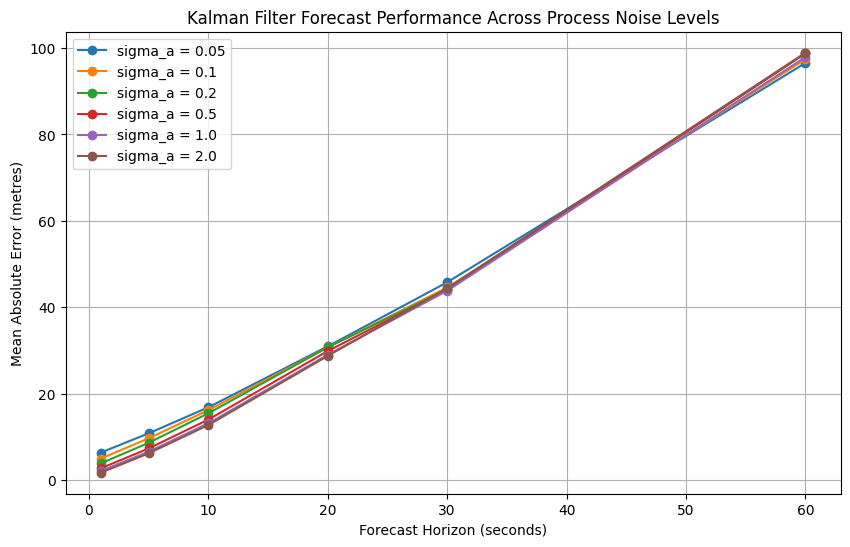

In [57]:
# Forecast horizons
horizons_plot = [1, 5, 10, 20, 30, 60]

plt.figure(figsize=(10, 6))

for sigma_a in model_comparison_df["sigma_a"]:

    row = model_comparison_df[
        model_comparison_df["sigma_a"] == sigma_a
    ].iloc[0]

    mae_values = [
        row[f"{h}s MAE"]
        for h in horizons_plot
    ]

    plt.plot(
        horizons_plot,
        mae_values,
        marker="o",
        label=f"sigma_a = {sigma_a}"
    )

plt.xlabel("Forecast Horizon (seconds)")
plt.ylabel("Mean Absolute Error (metres)")
plt.title("Kalman Filter Forecast Performance Across Process Noise Levels")

plt.legend()
plt.grid(True)

plt.show()

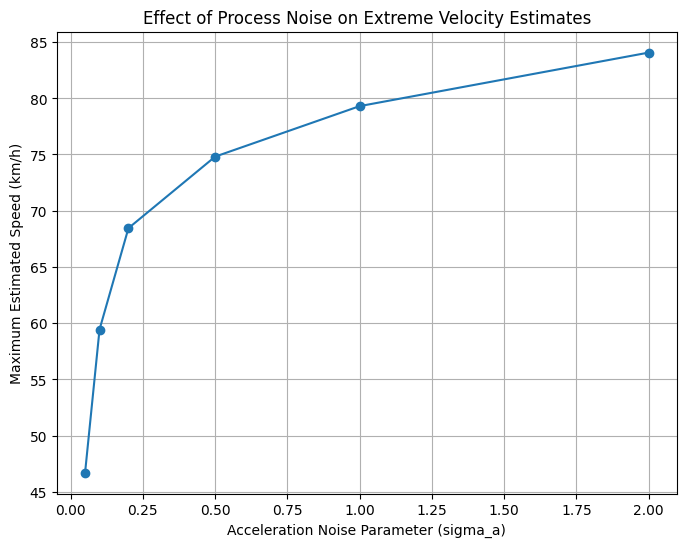

In [58]:
plt.figure(figsize=(8, 6))

plt.plot(
    model_comparison_df["sigma_a"],
    model_comparison_df["Max Speed (km/h)"],
    marker="o"
)

plt.xlabel("Acceleration Noise Parameter (sigma_a)")
plt.ylabel("Maximum Estimated Speed (km/h)")
plt.title("Effect of Process Noise on Extreme Velocity Estimates")

plt.grid(True)

plt.show()

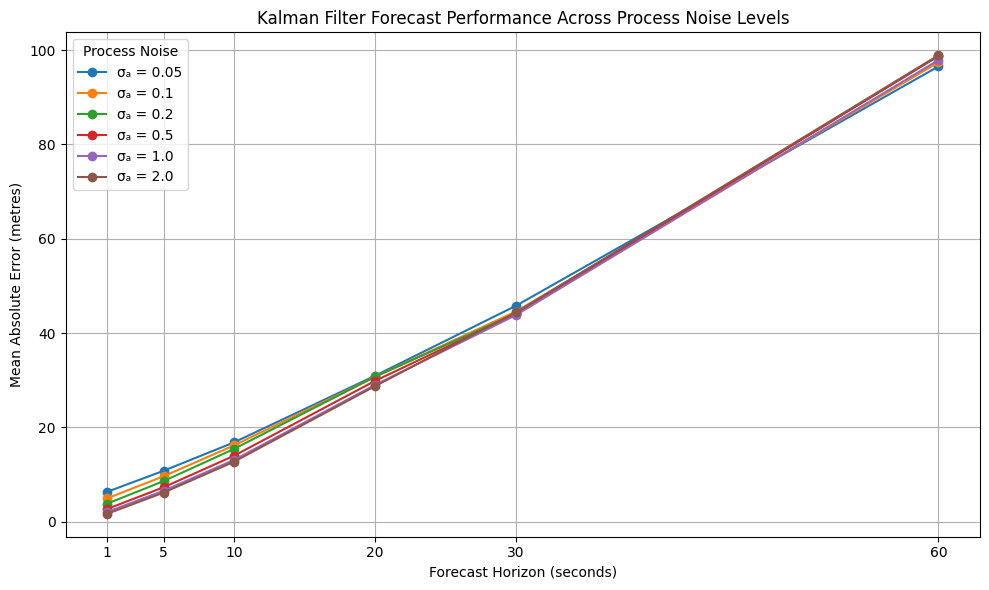

In [59]:
# Forecast horizons
horizons_plot = [1, 5, 10, 20, 30, 60]

plt.figure(figsize=(10, 6))

for sigma_a in model_comparison_df["sigma_a"]:

    row = model_comparison_df[
        model_comparison_df["sigma_a"] == sigma_a
    ].iloc[0]

    mae_values = [
        row[f"{h}s MAE"]
        for h in horizons_plot
    ]

    plt.plot(
        horizons_plot,
        mae_values,
        marker="o",
        label=f"σₐ = {sigma_a}"
    )

plt.xlabel("Forecast Horizon (seconds)")
plt.ylabel("Mean Absolute Error (metres)")
plt.title("Kalman Filter Forecast Performance Across Process Noise Levels")

plt.xticks(horizons_plot)

plt.legend(title="Process Noise")

plt.grid(True)

plt.tight_layout()

plt.show()

In [60]:
reliability_results = []

for sigma_a in sigma_values:
    
    for horizon in horizons:
        
        # Get the detailed forecasts
        forecast_df = all_forecast_details[sigma_a][horizon]
        
        # Extract forecast errors
        errors = forecast_df["forecast_error"].to_numpy()
        
        reliability_results.append({
            "sigma_a": sigma_a,
            "Horizon (s)": horizon,
            
            "Median Error (m)": np.median(errors),
            "90th Percentile (m)": np.percentile(errors, 90),
            "95th Percentile (m)": np.percentile(errors, 95),
            "99th Percentile (m)": np.percentile(errors, 99),
            
            "Max Error (m)": np.max(errors),
            
            "Errors > 100m": np.sum(errors > 100),
            "Errors > 250m": np.sum(errors > 250),
            "Errors > 500m": np.sum(errors > 500),
            
            "Number of Forecasts": len(errors)
        })


reliability_df = pd.DataFrame(reliability_results)

print(reliability_df.to_string(index=False))

 sigma_a  Horizon (s)  Median Error (m)  90th Percentile (m)  95th Percentile (m)  99th Percentile (m)  Max Error (m)  Errors > 100m  Errors > 250m  Errors > 500m  Number of Forecasts
    0.05            1          4.639132            12.467476            16.256349            32.931229      62.853698              0              0              0                 1993
    0.05            5          7.848487            21.067760            26.901751            55.886976      87.831830              0              0              0                 1813
    0.05           10         11.629798            33.570186            43.138622            89.916053     120.962249             10              0              0                 1602
    0.05           20         21.941495            64.838072            85.975673           157.393651     294.964903             51              5              0                 1578
    0.05           30         34.239052            98.476195           124.94975

In [61]:
long_horizon_reliability = reliability_df[
    reliability_df["Horizon (s)"].isin([30, 60])
].copy()

print(long_horizon_reliability.to_string(index=False))

 sigma_a  Horizon (s)  Median Error (m)  90th Percentile (m)  95th Percentile (m)  99th Percentile (m)  Max Error (m)  Errors > 100m  Errors > 250m  Errors > 500m  Number of Forecasts
    0.05           30         34.239052            98.476195           124.949753           190.146873     381.203123            152              6              0                 1573
    0.05           60         76.807561           194.394490           240.764559           377.056282     716.650609            619             76              5                 1683
    0.10           30         33.961717            94.685156           123.411141           207.696039     493.636832            138              6              0                 1573
    0.10           60         74.424135           189.040105           248.273623           441.350647     947.136614            621             82             14                 1683
    0.20           30         31.477881            95.220609           123.90229

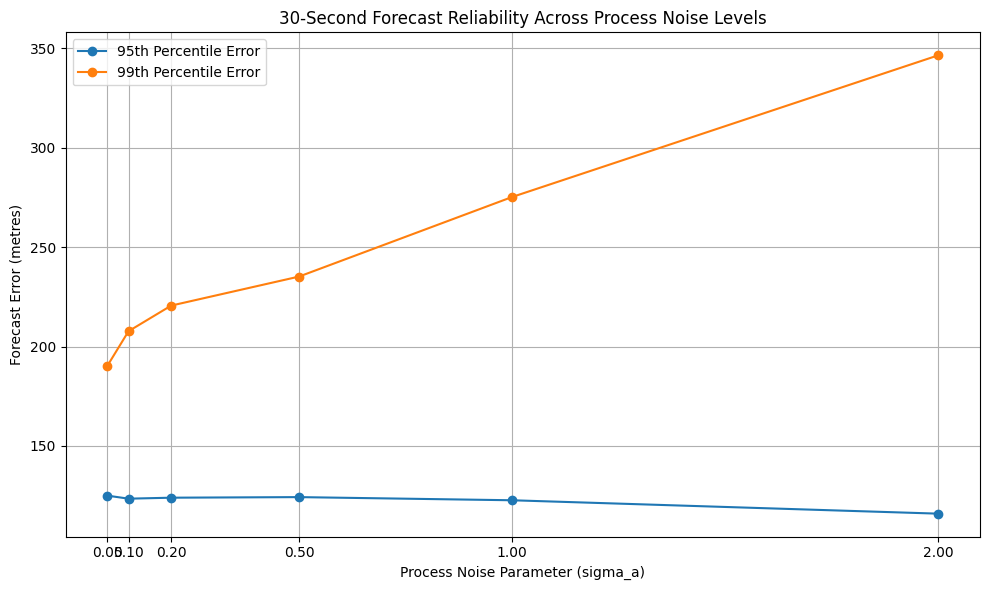

In [62]:
# Filter results for the 30-second horizon
reliability_30 = reliability_df[
    reliability_df["Horizon (s)"] == 30
].sort_values("sigma_a")

plt.figure(figsize=(10, 6))

plt.plot(
    reliability_30["sigma_a"],
    reliability_30["95th Percentile (m)"],
    marker="o",
    label="95th Percentile Error"
)

plt.plot(
    reliability_30["sigma_a"],
    reliability_30["99th Percentile (m)"],
    marker="o",
    label="99th Percentile Error"
)

plt.xlabel("Process Noise Parameter (sigma_a)")
plt.ylabel("Forecast Error (metres)")
plt.title("30-Second Forecast Reliability Across Process Noise Levels")

plt.xticks(reliability_30["sigma_a"])

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

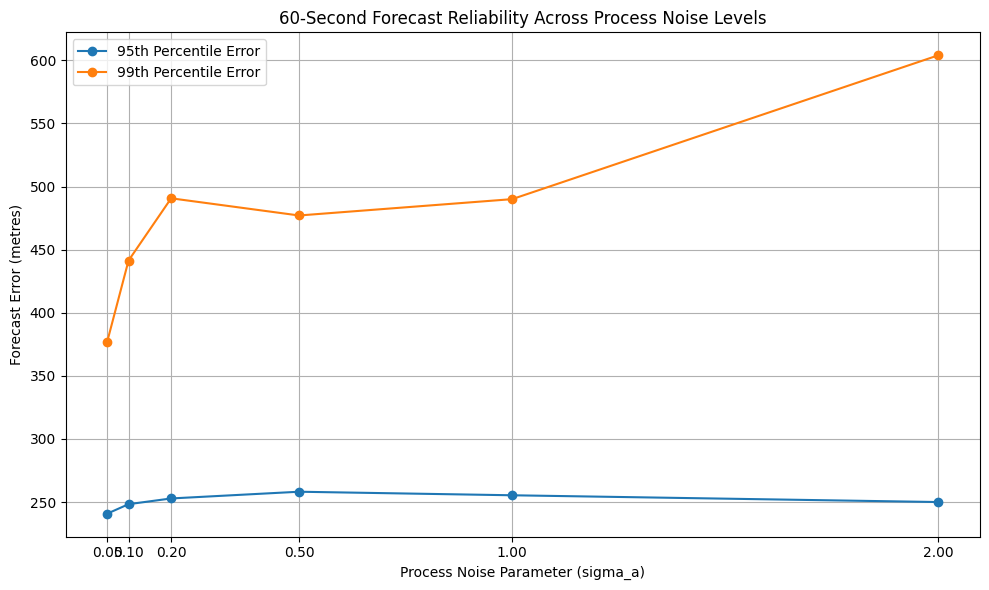

In [63]:
# Filter results for the 60-second horizon
reliability_60 = reliability_df[
    reliability_df["Horizon (s)"] == 60
].sort_values("sigma_a")

plt.figure(figsize=(10, 6))

plt.plot(
    reliability_60["sigma_a"],
    reliability_60["95th Percentile (m)"],
    marker="o",
    label="95th Percentile Error"
)

plt.plot(
    reliability_60["sigma_a"],
    reliability_60["99th Percentile (m)"],
    marker="o",
    label="99th Percentile Error"
)

plt.xlabel("Process Noise Parameter (sigma_a)")
plt.ylabel("Forecast Error (metres)")
plt.title("60-Second Forecast Reliability Across Process Noise Levels")

plt.xticks(reliability_60["sigma_a"])

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [67]:
print("First observation in y_obs:")
print(y_obs[0])

print("\nLast observation in y_obs:")
print(y_obs[-1])

print("\nFirst position in df_eval:")
print(df_eval[["x", "y"]].iloc[0])

print("\nLast position in df_eval:")
print(df_eval[["x", "y"]].iloc[-1])

First observation in y_obs:
[0. 0.]

Last observation in y_obs:
[ 1498.17242851 -1822.11419795]

First position in df_eval:
x   -3.834185
y   -0.370650
Name: 0, dtype: float64

Last position in df_eval:
x    1498.172429
y   -1822.114198
Name: 2057, dtype: float64


In [68]:
# Check whether y_obs matches df_eval from the beginning
print("Does y_obs[0] match df_eval[0]?")
print(np.allclose(y_obs[0], df_eval[["x", "y"]].iloc[0].to_numpy()))

print("\nDoes y_obs[1:] match df_eval?")
print(
    np.allclose(
        y_obs[1:],
        df_eval[["x", "y"]].to_numpy()
    )
)

Does y_obs[0] match df_eval[0]?
False

Does y_obs[1:] match df_eval?
True


In [69]:
# Create dataframe for the primary model
df_primary = df_eval.copy()

# Align Kalman Filter states with df_eval
x_filt_aligned = x_filt_primary[1:]

# Add aligned Kalman states
df_primary["kf_x"] = x_filt_aligned[:, 0]
df_primary["kf_y"] = x_filt_aligned[:, 1]
df_primary["kf_vx"] = x_filt_aligned[:, 2]
df_primary["kf_vy"] = x_filt_aligned[:, 3]

print("DataFrame shape:", df_primary.shape)
print("Aligned filtered states shape:", x_filt_aligned.shape)

DataFrame shape: (2058, 13)
Aligned filtered states shape: (2058, 4)


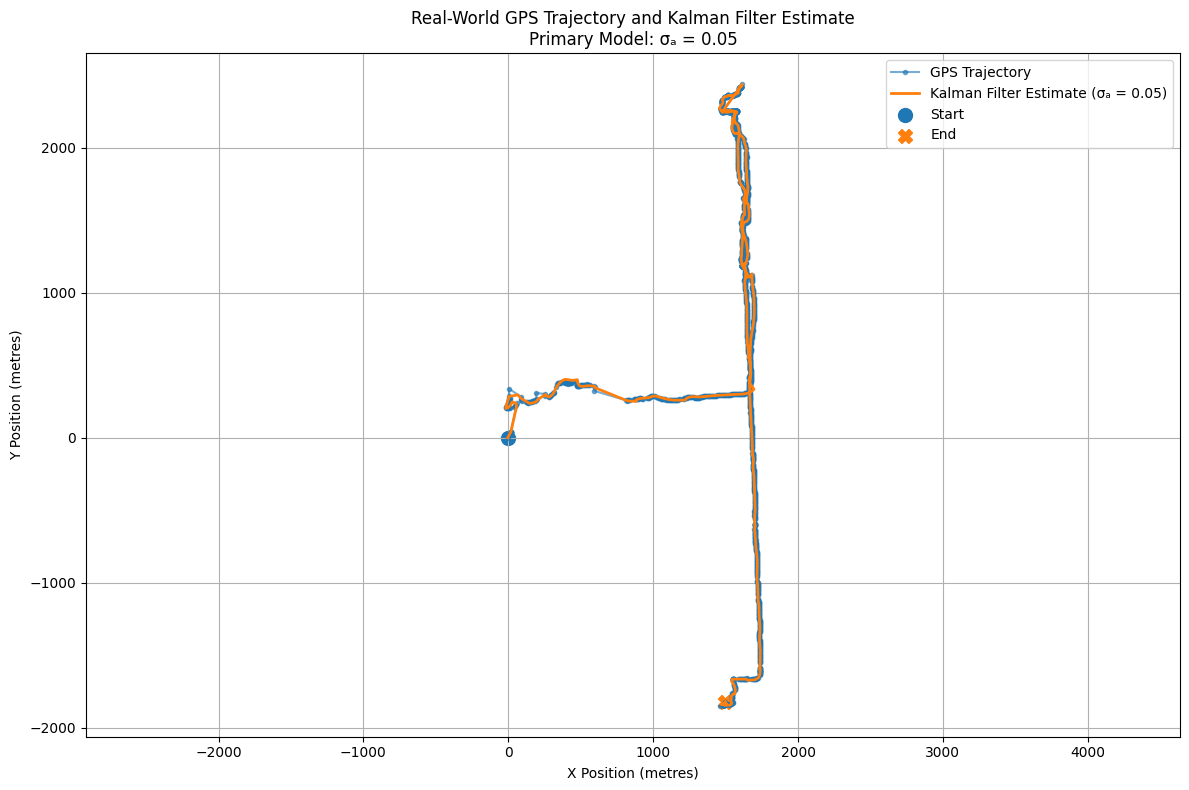

In [70]:
plt.figure(figsize=(12, 8))

# Raw GPS trajectory
plt.plot(
    df_primary["x"],
    df_primary["y"],
    marker=".",
    linestyle="-",
    alpha=0.6,
    label="GPS Trajectory"
)

# Kalman Filter trajectory
plt.plot(
    df_primary["kf_x"],
    df_primary["kf_y"],
    linewidth=2,
    label="Kalman Filter Estimate (σₐ = 0.05)"
)

# Start
plt.scatter(
    df_primary["x"].iloc[0],
    df_primary["y"].iloc[0],
    marker="o",
    s=100,
    label="Start"
)

# End
plt.scatter(
    df_primary["x"].iloc[-1],
    df_primary["y"].iloc[-1],
    marker="X",
    s=100,
    label="End"
)

plt.xlabel("X Position (metres)")
plt.ylabel("Y Position (metres)")

plt.title(
    "Real-World GPS Trajectory and Kalman Filter Estimate\n"
    "Primary Model: σₐ = 0.05"
)

plt.legend()
plt.grid(True)
plt.axis("equal")

plt.tight_layout()
plt.show()

In [71]:
import pandas as pd

# Final model selection summary

summary_data = {
    "Criterion": [
        "Selected Process Noise (σₐ)",
        "1-Second MAE (m)",
        "30-Second MAE (m)",
        "60-Second MAE (m)",
        "Maximum Estimated Speed (km/h)",
        "Estimated Speeds > 40 km/h",
        "Estimated Speeds > 50 km/h",
        "60-Second 95th Percentile Error (m)",
        "60-Second 99th Percentile Error (m)",
        "60-Second Maximum Forecast Error (m)"
    ],
    
    "Primary Model (σₐ = 0.05)": [
        0.05,
        6.35,
        45.78,
        96.55,
        46.72,
        4,
        0,
        240.76,
        377.06,
        716.65
    ]
}

model_summary = pd.DataFrame(summary_data)

print("FINAL MODEL SELECTION SUMMARY")
display(model_summary)

FINAL MODEL SELECTION SUMMARY


,Criterion,Primary Model (σₐ = 0.05)
0,Selected Process Noise (σₐ),0.05
1,1-Second MAE (m),6.35
2,30-Second MAE (m),45.78
3,60-Second MAE (m),96.55
4,Maximum Estimated Speed (km/h),46.72
5,Estimated Speeds > 40 km/h,4.00
6,Estimated Speeds > 50 km/h,0.00
7,60-Second 95th Percentile Error (m),240.76
8,60-Second 99th Percentile Error (m),377.06
9,60-Second Maximum Forecast Error (m),716.65
